LOCAL FERIA

Utilizing OpenCV and Pillow, this code below creates an application that captures live video from the webcam, displays overlaid instructions on the video feed, allows the user to save a person-free, well-framed bed calibration photo in RGB format by pressing the 'c' key, and stores the image in a specified file path.

In [1]:
import cv2
import ultralytics
import os
import PIL
import numpy as np
import math
import time
import mailtrap as mt
import requests
import torch
import math

from ultralytics import YOLO
from yolov6.utils.events import LOGGER, load_yaml
from yolov6.layers.common import DetectBackend
from yolov6.data.data_augment import letterbox
from yolov6.utils.nms import non_max_suppression
from yolov6.core.inferer import Inferer
from typing import List, Optional

In [3]:
class PhotoCaptureApp:
    def __init__(self, save_folder):
        self.save_folder = save_folder

        # Set up OpenCV to capture video
        self.cap = cv2.VideoCapture(0)

        while not self.cap.isOpened():
            pass

        # Set the window size
        self.cap.set(3, 640)
        self.cap.set(4, 480)

        # Define font and color
        self.font = cv2.FONT_HERSHEY_SIMPLEX
        self.font_size = 0.8
        self.font_thickness = 2
        self.font_color = (57, 255, 20)  # Neon Green
        self.font_outline_thickness = 3
        self.font_outline_color = (0, 0, 0)

    def update(self):
        ret, frame = self.cap.read()

        if ret:
            # Convert BGR image to RGB
            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Add text to the image
            text_line1 = "Capture a person-free, well-framed"
            text_line2 = "bed calibration photo by pressing 'c'."
            text = f"{text_line1}\n{text_line2}"

            text_position = (10, 20)  # Adjusted position

            cv2.putText(img, text_line1, (text_position[0], text_position[1] + 30), self.font, self.font_size,
                        self.font_outline_color, self.font_outline_thickness, cv2.LINE_AA)
            cv2.putText(img, text_line2, (text_position[0], text_position[1] + 60), self.font, self.font_size,
                        self.font_outline_color, self.font_outline_thickness, cv2.LINE_AA)

            cv2.putText(img, text_line1, (text_position[0], text_position[1] + 30), self.font, self.font_size,
                        self.font_color, self.font_thickness, cv2.LINE_AA)
            cv2.putText(img, text_line2, (text_position[0], text_position[1] + 60), self.font, self.font_size,
                        self.font_color, self.font_thickness, cv2.LINE_AA)

            # Save the image without overlay text directly to the specified folder
            save_path = os.path.join(self.save_folder, "calibration_image.jpg")
            cv2.imwrite(save_path, frame)

            # Display the image in a separate OpenCV window (converted back to BGR for display)
            cv2.imshow("Photo Capture", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    def run(self):
        while True:
            self.update()
            key = cv2.waitKey(1) & 0xFF
            if key == ord('c'):
                # Capture the current frame, save it, and exit
                ret, frame = self.cap.read()
                if ret:
                    # Save the image directly to the specified folder
                    save_path = os.path.join(self.save_folder, "calibration_image.jpg")
                    cv2.imwrite(save_path, frame)
                    print(f"Image saved to {save_path}")
                    break

        # Release the camera and close OpenCV windows
        self.cap.release()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    save_folder = "data/yolov6/fotos_out/crop_out/bed_calibration"
    app = PhotoCaptureApp(save_folder)
    app.run()

Image saved to data/yolov6/fotos_out/crop_out/bed_calibration/calibration_image.jpg


The code sets up and runs YOLOv6 Lite on a provided image for object detection, displaying the inference results with bounding boxes and class labels.

sh: wget: command not found
checkpoint yolov6n.pt not exist, try to downloaded it from github.
downloading url is: https://github.com/meituan/YOLOv6/releases/download/0.4.0/yolov6n.pt, pealse make sure the version of the downloading model is correspoing to the code version!


checkpoint yolov6n.pt downloaded and saved
Loading checkpoint from ./yolov6n.pt

Fusing model...
/Users/emibetroldan/YEM/YEM/.conda/lib/python3.12/site-packages/torch/nn/modules/module.py:836: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  if param.grad is not None:


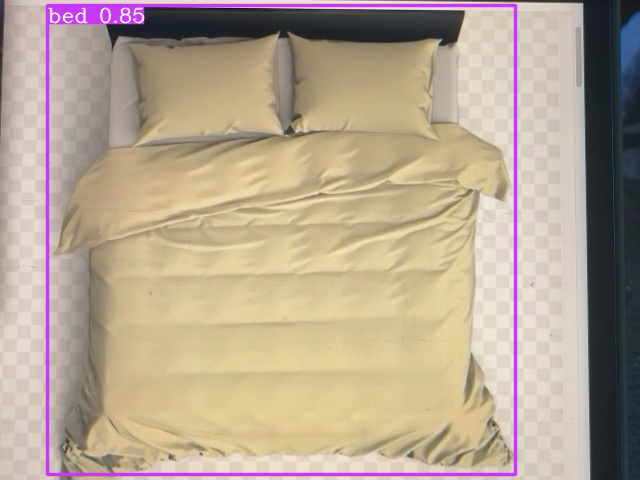

In [4]:
#@title Set-up model. { run: "auto" }
checkpoint:str ="yolov6n" #@param ["yolov6s", "yolov6n", "yolov6t"]
device:str = "cpu"#@param ["gpu", "cpu"]
half:bool = False #@param {type:"boolean"}

#Change directory so that imports wortk correctly
if os.getcwd()=="/content":
  os.chdir("YOLOv6")

# Set the local image path
image_path = "data/yolov6/fotos_out/crop_out/bed_calibration/calibration_image.jpg"

# Download weights
if not os.path.exists(f"{checkpoint}.pt"):
  print("Downloading checkpoint...")
  os.system(f"""wget -c https://github.com/meituan/YOLOv6/releases/download/0.4.0/{checkpoint}.pt""")

# Set-up hardware options
cuda = device != 'cpu' and torch.cuda.is_available()
device = torch.device('cuda:0' if cuda else 'cpu')

def check_img_size(img_size, s=32, floor=0):
  def make_divisible( x, divisor):
    # Upward revision the value x to make it evenly divisible by the divisor.
    return math.ceil(x / divisor) * divisor
  """Make sure image size is a multiple of stride s in each dimension, and return a new shape list of image."""
  if isinstance(img_size, int):  # integer i.e. img_size=640
      new_size = max(make_divisible(img_size, int(s)), floor)
  elif isinstance(img_size, list):  # list i.e. img_size=[640, 480]
      new_size = [max(make_divisible(x, int(s)), floor) for x in img_size]
  else:
      raise Exception(f"Unsupported type of img_size: {type(img_size)}")

  if new_size != img_size:
      print(f'WARNING: --img-size {img_size} must be multiple of max stride {s}, updating to {new_size}')
  return new_size if isinstance(img_size,list) else [new_size]*2


def process_image(path, img_size, stride, half):
  '''Process image before image inference.'''
  try:
    img_src = np.asarray(PIL.Image.open(path))
    assert img_src is not None, f'Invalid image: {path}'
  except Exception as e:
    LOGGER.warning(e)
    return None, None  # Return None for both image and img_src in case of an exception

  image = letterbox(img_src, img_size, stride=stride)[0]

  # Convert
  image = image.transpose((2, 0, 1))  # HWC to CHW
  image = torch.from_numpy(np.ascontiguousarray(image))
  image = image.half() if half else image.float()  # uint8 to fp16/32
  image /= 255  # 0 - 255 to 0.0 - 1.0

  return image, img_src


model = DetectBackend(f"./{checkpoint}.pt", device=device)
stride = model.stride
class_names = load_yaml("data/yolov6/data/coco.yaml")['names']

if half & (device.type != 'cpu'):
  model.model.half()
else:
  model.model.float()
  half = False

img_size:int = 640#@param {type:"integer"}

if device.type != 'cpu':
  model(torch.zeros(1, 3, *img_size).to(device).type_as(next(model.model.parameters())))  # warmup

#@title Run YOLOv6 on an image from a local path. { run: "auto" }
hide_labels: bool = False #@param {type:"boolean"}
hide_conf: bool = False #@param {type:"boolean"}

img_size:int = 640#@param {type:"integer"}

conf_thres: float =.60 #@param {type:"number"}
iou_thres: float =.80 #@param {type:"number"}
max_det:int =  1000#@param {type:"integer"}
agnostic_nms: bool = False #@param {type:"boolean"}

img_size = check_img_size(img_size, s=stride)

img, img_src = process_image(image_path, img_size, stride, half)
img = img.to(device)
if len(img.shape) == 3:
    img = img[None]
    # expand for batch dim
pred_results = model(img)
classes:Optional[List[int]] = None # the classes to keep
det = non_max_suppression(pred_results, conf_thres, iou_thres, classes, agnostic_nms, max_det=max_det)[0]

gn = torch.tensor(img_src.shape)[[1, 0, 1, 0]]  # normalization gain whwh
img_ori = img_src.copy()
if len(det):
  det[:, :4] = Inferer.rescale(img.shape[2:], det[:, :4], img_src.shape).round()
  for *xyxy, conf, cls in reversed(det):
      class_num = int(cls)
      label = None if hide_labels else (class_names[class_num] if hide_conf else f'{class_names[class_num]} {conf:.2f}')
      Inferer.plot_box_and_label(img_ori, max(round(sum(img_ori.shape) / 2 * 0.003), 2), xyxy, label, color=Inferer.generate_colors(class_num, True))
PIL.Image.fromarray(img_ori)

This code processes object detection results from a YOLO model, saving the output image with bounding boxes, creating a YOLO annotation file, and cropping and saving individual detected regions based on class labels in specified folders.

In [5]:
def read_yolo_annotation(annotation_path, image_width, image_height):
    with open(annotation_path, 'r') as file:
        lines = file.readlines()

    bounding_boxes = []
    for line in lines:
        data = line.strip().split()
        class_index = int(data[0])
        x_center, y_center, width, height = map(float, data[1:])
        
        # Convert from normalized coordinates to image coordinates
        x_min = int((x_center - width / 2) * image_width)
        y_min = int((y_center - height / 2) * image_height)
        x_max = int((x_center + width / 2) * image_width)
        y_max = int((y_center + height / 2) * image_height)

        bounding_boxes.append((class_index, x_min, y_min, x_max, y_max))

    return bounding_boxes

# Function to save YOLO annotation file for the bed class only
def save_bed_annotation(annotation_path, det, img_width, img_height, bed_index):
    with open(annotation_path, 'w') as file:
        for *xyxy, conf, cls in reversed(det):
            class_num = int(cls)

            # Check if the detected class is the bed class
            if class_num == bed_index:
                # Calculate XYWH format directly from XYXY
                x_center = (xyxy[0] + xyxy[2]) / 2
                y_center = (xyxy[1] + xyxy[3]) / 2
                width = xyxy[2] - xyxy[0]
                height = xyxy[3] - xyxy[1]

                # Normalize coordinates to [0, 1]
                x_center /= img_width
                y_center /= img_height
                width /= img_width
                height /= img_height

                line = f"{class_num} {x_center} {y_center} {width} {height}\n"
                file.write(line)

# Function to generate output paths dynamically
def generate_output_paths(crop_out_folder, class_name, index):
    class_folder = os.path.join(crop_out_folder, class_name)
    os.makedirs(class_folder, exist_ok=True)
    output_path = os.path.join(class_folder, f'{class_name}_{index}.jpg')
    return output_path

# Replace these paths with your actual folder paths
jpg_output_images_folder = 'data/yolov6/fotos_out/yolo_out/jpg_files'
txt_output_annotations_folder = 'data/yolov6/fotos_out/yolo_out/txt_files'
crop_out_folder = 'data/yolov6/fotos_out/crop_out'

os.makedirs(jpg_output_images_folder, exist_ok=True)
os.makedirs(txt_output_annotations_folder, exist_ok=True)

# ...

# Save image to JPEG
output_image_path = os.path.join(jpg_output_images_folder, 'output_image.jpg')
cv2.imwrite(output_image_path, cv2.cvtColor(img_ori, cv2.COLOR_RGB2BGR))

# Save YOLO annotation file for the bed class only
output_annotation_path = os.path.join(txt_output_annotations_folder, 'output_image.txt')
save_bed_annotation(output_annotation_path, det, img_ori.shape[1], img_ori.shape[0], 59)

# Display the processed image
PIL.Image.fromarray(cv2.cvtColor(img_ori, cv2.COLOR_BGR2RGB))

# Read YOLO annotation
bounding_boxes = read_yolo_annotation(output_annotation_path, img_ori.shape[1], img_ori.shape[0])

# Crop and save regions only if the detected class is a bed
for i, (class_index, x_min, y_min, x_max, y_max) in enumerate(bounding_boxes):
    class_name = class_names[class_index]
    
    # Check if the detected class is a bed (replace 'bed_index' with the actual index of the bed class)
    if class_index == 59:
        output_path = generate_output_paths(crop_out_folder, class_name, i)
        cropped_region = img_ori[y_min:y_max, x_min:x_max]
        cv2.imwrite(output_path, cv2.cvtColor(cropped_region, cv2.COLOR_BGR2RGB))

This code reads YOLO annotation data from a text file, containing normalized coordinates, and calculates the corresponding image coordinates for bounding boxes, then prints the class names and image coordinates for each bounding box.

In [6]:
def calculate_coordinates_from_yolo_annotation(annotation_path, image_width, image_height):
    with open(annotation_path, 'r') as file:
        lines = file.readlines()

    bounding_boxes = []
    for line in lines:
        data = line.strip().split()
        class_index = int(data[0])
        x_center, y_center, width, height = map(float, data[1:])
        
        # Convert from normalized coordinates to image coordinates
        x_min = int((x_center - width / 2) * image_width)
        y_min = int((y_center - height / 2) * image_height)
        x_max = int((x_center + width / 2) * image_width)
        y_max = int((y_center + height / 2) * image_height)

        bounding_boxes.append((class_index, x_min, y_min, x_max, y_max))

    return bounding_boxes

# Replace these paths with your actual file paths
annotation_path = 'data/yolov6/fotos_out/yolo_out/txt_files/output_image.txt'
image_width = 640  # Replace with the actual width of your image
image_height = 480  # Replace with the actual height of your image

# Read YOLO annotation and calculate coordinates
bounding_boxes = calculate_coordinates_from_yolo_annotation(annotation_path, image_width, image_height)

# Print calculated bounding box coordinates
for i, (class_index, x_min, y_min, x_max, y_max) in enumerate(bounding_boxes):
    print(f"Bounding Box {i + 1}: Class {class_names[class_index]}, Coordinates (x_min, y_min, x_max, y_max): ({x_min}, {y_min}, {x_max}, {y_max})")

bed_coords = (x_min, y_min, x_max, y_max)

Bounding Box 1: Class bed, Coordinates (x_min, y_min, x_max, y_max): (47, 4, 515, 473)


Esto hac eimput al modelo final en vivo!!!!

In [ ]:
# Start webcam
cap = cv2.VideoCapture(1)
cap.set(3, 640)
cap.set(4, 480)

# Model
model = YOLO("yolo-Weights/yolov8n.pt")

# Object class
classNames = ["person"]

# Permanent boundary box for bed
bed_box_coords = (bed_coords)

fall_alert_time = 0
out_of_bed_alert_time = 0

fall_alert_interval = 30  # seconds
out_of_bed_alert_interval = 30  # seconds

while True:
    success, img = cap.read()
    results = model(img, stream=True)

    person_detected = False
    person_box = None

    # Draw the permanent boundary box for the bed
    bed_color = (255, 255, 255)
    bed_thickness = 2
    cv2.rectangle(img, (bed_box_coords[0], bed_box_coords[1]), (bed_box_coords[2], bed_box_coords[3]), bed_color, bed_thickness)

    # Mark the boundary box of the bed with the word "Bed"
    bed_text = "Bed"
    bed_text_color = (255, 255, 255)  # White text
    bed_text_font = cv2.FONT_HERSHEY_SIMPLEX
    bed_text_scale = 1
    bed_text_thickness = 2

    # Get the size of the text box
    (text_width, text_height), baseline = cv2.getTextSize(bed_text, bed_text_font, bed_text_scale, bed_text_thickness)

    # Calculate the position to the right of the boundary box
    bed_text_x = bed_box_coords[2] + 10  # Adjust the offset as needed
    bed_text_y = (bed_box_coords[1] + bed_box_coords[3] - text_height) // 2

    # Draw the outlined text
    bed_text_border_thickness = 5
    cv2.putText(img, bed_text, (bed_text_x, bed_text_y), bed_text_font, bed_text_scale, (0, 0, 0), bed_text_border_thickness + 2, cv2.LINE_AA)
    cv2.putText(img, bed_text, (bed_text_x, bed_text_y), bed_text_font, bed_text_scale, bed_text_color, bed_text_thickness, cv2.LINE_AA)

    # Coordinates
    for r in results:
        boxes = r.boxes

        for box in boxes:
            # Bounding box
            x1, y1, x2, y2 = box.xyxy[0]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)  # Convert to int values

            # Confidence
            confidence = math.ceil((box.conf[0] * 100)) / 100

            # Ensure class index is within the valid range
            class_index = int(box.cls[0])
            if class_index < 0 or class_index >= len(classNames):
                continue  # Skip if index is out of range

            # Show bounding box only if confidence is 60 or more and class is "person"
            if confidence >= 0.6 and classNames[class_index] == "person":
                # Put box in the camera
                color = (255, 0, 255)  # Pink for person
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

                # Class name
                cls = classNames[class_index]

                # Check for person detection
                if cls == "person":
                    person_detected = True
                    person_box = (x1, y1, x2, y2)

                # Display class name, confidence, and overlap area with enhanced styling
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 1.2  # Adjust the font size here
                font_thickness = 2

                # Draw class name with neon color and bold text with black border
                text_color = (255, 192, 203)  # Pink for person
                border_thickness = 5
                cv2.putText(img, cls, (x1, y1 - 10), font, font_scale, (0, 0, 0), border_thickness + 2, cv2.LINE_AA)
                cv2.putText(img, cls, (x1, y1 - 10), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

                # Display confidence percentage with black border
                cv2.putText(img, f"{confidence*100:.2f}%", (x1, y1 + 25), font, font_scale, (0, 0, 0), border_thickness, cv2.LINE_AA)
                cv2.putText(img, f"{confidence*100:.2f}%", (x1, y1 + 25), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

    # Check the position of the person relative to the bed boundary box
    if person_detected:
        px1, py1, px2, py2 = person_box

        # Check if person is in bed, out of bed, or getting out of bed
        if px1 >= bed_box_coords[0] and py1 >= bed_box_coords[1] and px2 <= bed_box_coords[2] and py2 <= bed_box_coords[3]:
            status = "Patient is in bed."
            status_color = (0, 255, 0)  # Green
        elif px1 > bed_box_coords[2] or px2 < bed_box_coords[0] or py1 > bed_box_coords[3] or py2 < bed_box_coords[1]:
            status = "Alert! Patient is out of the bed!"
            status_color = (0, 0, 255)  # Red

            # Check if it's time to send a fall alert or if a fall just occurred
            if time.time() - fall_alert_time >= fall_alert_interval or fall_alert_time == 0:
                # Send alert email for fallen patient
                caregiver_name = "Ms. Emibet"
                mail = mt.MailFromTemplate(
                    sender=mt.Address(email="mailtrap@demomailtrap.com", name="Mailtrap Test"),
                    to=[mt.Address(email="sciencefair2024@yahoo.com")],
                    template_uuid="8302914b-6dc1-4c05-89c3-1b6260803268",
                    template_variables={"Caregiver_name": caregiver_name}
                )
                client = mt.MailtrapClient(token="1467c284eb77bd4de72abdac13ab416b")
                client.send(mail)

                fall_alert_time = time.time()  # Update last alert time

        else:
            status = "Grandma is getting out of bed!"
            status_color = (0, 165, 255)  # Orange

            # Check if it's time to send an out-of-bed alert
            if time.time() - out_of_bed_alert_time >= out_of_bed_alert_interval:
                # Send alert email for going out of bed
                caregiver_name = "Ms. Emibet"
                mail = mt.MailFromTemplate(
                    sender=mt.Address(email="mailtrap@demomailtrap.com", name="Mailtrap Test"),
                    to=[mt.Address(email="sciencefair2024@yahoo.com")],
                    template_uuid="0a471fa2-94dd-4d88-92c2-9bdab62ef810",
                    template_variables={"Caregiver_name": caregiver_name}
                )
                client = mt.MailtrapClient(token="1467c284eb77bd4de72abdac13ab416b")
                client.send(mail)

                out_of_bed_alert_time = time.time()  # Update last alert time

        # Display the status with enhanced styling in the bottom left corner
        cv2.putText(img, f"{status}", (10, 480 - 10), font, 1, (0, 0, 0), 5, cv2.LINE_AA)
        cv2.putText(img, f"{status}", (10, 480 - 10), font, 1, status_color, 2, cv2.LINE_AA)

    cv2.imshow('Webcam', img)
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

__

In [ ]:
import cv2

# Load the image
image = cv2.imread('YOLOv6/fotos_out/crop_out/bed_calibration/calibration_image.jpg')

# Coordinates
x, y = (452.1568298339844, 262.64239501953125)

# Draw a dot on the image at the specified coordinates
cv2.circle(image, (int(x), int(y)), 5, (0, 255, 0), -1)  # Assuming green color (BGR)

# Display the image
cv2.imshow('Image with Dot', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [8]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model('data/yolov6/assets/man1.jpg')  # results list

# View results
for r in results:
    print(r.keypoints.xy)  # print the Keypoints object containing the detected keypoints


image 1/1 /Users/emibetroldan/YEM/YEM/data/yolov6/assets/man1.jpg: 640x416 1 person, 79.8ms
Speed: 2.4ms preprocess, 79.8ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 416)
tensor([[[ 452.15683,  262.64240],
         [ 484.98999,  230.31432],
         [ 416.20535,  234.23003],
         [ 542.36658,  253.33167],
         [ 375.14075,  257.62070],
         [ 618.72217,  430.53003],
         [ 275.26730,  408.95898],
         [ 703.01642,  688.79395],
         [ 132.07115,  621.81213],
         [ 770.53021,  923.49054],
         [ 292.91632,  776.22974],
         [ 561.73151,  823.85370],
         [ 321.47977,  826.80756],
         [   0.00000,    0.00000],
         [ 250.43324, 1088.95020],
         [   0.00000,    0.00000],
         [   0.00000,    0.00000]]])



image 1/1 /Users/emibetroldan/prueba/YOLOv6/man1.jpg: 640x416 1 person, 98.7ms
Speed: 2.7ms preprocess, 98.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 416)


NameError: name 'nose_coords' is not defined

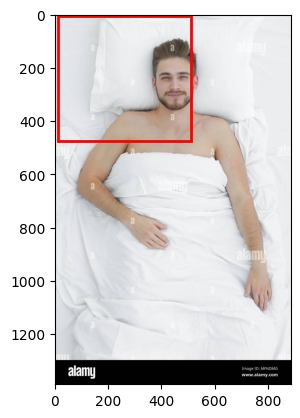

In [30]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model('man1.jpg')  # assuming 'man1.jpg' is your image

# Bed boundary box coordinates (x1, y1, x2, y2)
bed_box_coords = (bed_coords)

# Extract coordinates from the results list
keypoints = results[0].keypoints.xy[0]

# Create a figure and axis
fig, ax = plt.subplots()

# Display the image
image = plt.imread('man1.jpg')  # assuming 'man1.jpg' is your image
ax.imshow(image)

# Display the bed boundary box
bed_box = patches.Rectangle((bed_box_coords[0], bed_box_coords[1]),
                            bed_box_coords[2] - bed_box_coords[0],
                            bed_box_coords[3] - bed_box_coords[1],
                            linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(bed_box)

# Lists to store whether each keypoint is inside (True) or outside (False) the bed
in_bed_list = []

# Check each keypoint against the bed boundary box
for coord in [nose_coords, left_eye_coords, right_eye_coords, left_ear_coords, right_ear_coords,
              left_shoulder_coords, right_shoulder_coords, left_elbow_coords, right_elbow_coords,
              left_wrist_coords, right_wrist_coords, left_hip_coords, right_hip_coords,
              left_knee_coords, right_knee_coords, left_ankle_coords, right_ankle_coords]:
    
    in_bed = (bed_box_coords[0] <= coord[0] <= bed_box_coords[2] and
              bed_box_coords[1] <= coord[1] <= bed_box_coords[3])
    
    in_bed_list.append(in_bed)

# Display the result for each keypoint
for i, result in enumerate(in_bed_list):
    print(f"Keypoint {i + 1}: {'In bed' if result else 'Outside bed'}")

# Show the image with the bed boundary box
plt.show()


In [ ]:
import cv2
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Initialize webcam capture
cap = cv2.VideoCapture(0)
cap.set(3, 640)
cap.set(4, 480)

# Permanent boundary box for bed
bed_box_coords = (bed_coords) # Replace with actual bed coordinates

while True:
    success, img = cap.read()
    results = model(img, stream=True)

    person_detected = False

    # Draw the permanent boundary box for the bed
    bed_color = (255, 255, 255)
    bed_thickness = 2
    cv2.rectangle(img, (bed_coords[0], bed_coords[1]), (bed_coords[2], bed_coords[3]), bed_color, bed_thickness)

    # Mark the boundary box of the bed with the word "Bed"
    bed_text = "Bed"
    bed_text_color = (255, 255, 255)  # White text
    bed_text_font = cv2.FONT_HERSHEY_SIMPLEX
    bed_text_scale = 1
    bed_text_thickness = 2

    # Get the size of the text box
    (text_width, text_height), baseline = cv2.getTextSize(bed_text, bed_text_font, bed_text_scale, bed_text_thickness)

    # Calculate the position to the right of the boundary box
    bed_text_x = bed_coords[2] + 10  # Adjust the offset as needed
    bed_text_y = (bed_coords[1] + bed_coords[3] - text_height) // 2

    # Draw the outlined text
    bed_text_border_thickness = 5
    cv2.putText(img, bed_text, (bed_text_x, bed_text_y), bed_text_font, bed_text_scale, (0, 0, 0), bed_text_border_thickness + 2, cv2.LINE_AA)
    cv2.putText(img, bed_text, (bed_text_x, bed_text_y), bed_text_font, bed_text_scale, bed_text_color, bed_text_thickness, cv2.LINE_AA)

    # Coordinates
    for r in results:
        keypoints = r.keypoints
        person_detected = any((x1 >= bed_coords[0] and y1 >= bed_coords[1] and x1 <= bed_coords[2] and y1 <= bed_coords[3])
                              for x1, y1, _, _ in keypoints)

        # Display status based on keypoints
        if person_detected:
            status = "Grandma is in bed."
            status_color = (0, 255, 0)  # Green
        else:
            status = "Grandma is getting out of bed!"
            status_color = (0, 165, 255)  # Orange

        # Display the status with enhanced styling in the bottom left corner
        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(img, f"{status}", (10, 480 - 10), font, 1, (0, 0, 0), 5, cv2.LINE_AA)
        cv2.putText(img, f"{status}", (10, 480 - 10), font, 1, status_color, 2, cv2.LINE_AA)

    cv2.imshow('Webcam', img)
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


In [29]:
print(bed_box_coords)

(12, 4, 510, 475)


In [ ]:
import cv2
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Initialize webcam capture
cap = cv2.VideoCapture(0)
cap.set(3, 640)
cap.set(4, 480)

# Permanent boundary box for bed
bed_box_coords = (bed_coords)

while True:
    success, img = cap.read()
    results = model(img, stream=True)

    person_detected = False

    # Draw the permanent boundary box for the bed
    bed_color = (255, 255, 255)
    bed_thickness = 2
    cv2.rectangle(img, (bed_coords[0], bed_coords[1]), (bed_coords[2], bed_coords[3]), bed_color, bed_thickness)

    # Mark the boundary box of the bed with the word "Bed"
    bed_text = "Bed"
    bed_text_color = (255, 255, 255)  # White text
    bed_text_font = cv2.FONT_HERSHEY_SIMPLEX
    bed_text_scale = 1
    bed_text_thickness = 2

    # Get the size of the text box
    (text_width, text_height), baseline = cv2.getTextSize(bed_text, bed_text_font, bed_text_scale, bed_text_thickness)

    # Calculate the position to the right of the boundary box
    bed_text_x = bed_coords[2] + 10  # Adjust the offset as needed
    bed_text_y = (bed_coords[1] + bed_coords[3] - text_height) // 2

    # Draw the outlined text
    bed_text_border_thickness = 5
    cv2.putText(img, bed_text, (bed_text_x, bed_text_y), bed_text_font, bed_text_scale, (0, 0, 0), bed_text_border_thickness + 2, cv2.LINE_AA)
    cv2.putText(img, bed_text, (bed_text_x, bed_text_y), bed_text_font, bed_text_scale, bed_text_color, bed_text_thickness, cv2.LINE_AA)

    # Coordinates
    for r in results:
        keypoints = r.keypoints

        # Handle different representations of keypoints
        if isinstance(keypoints, list):  # List of lists
            person_detected = any((x >= bed_coords[0] and y >= bed_coords[1] and x <= bed_coords[2] and y <= bed_coords[3])
                                  for x, y, _, _ in keypoints)
        elif isinstance(keypoints, torch.Tensor):  # Assuming it's a tensor
            person_detected = any((x >= bed_coords[0] and y >= bed_coords[1] and x <= bed_coords[2] and y <= bed_coords[3])
                                  for x, y, _, _ in keypoints.squeeze(0))

        # Display status based on keypoints
        if person_detected:
            status = "Grandma is in bed."
            status_color = (0, 255, 0)  # Green
        else:
            status = "Grandma is getting out of bed!"
            status_color = (0, 165, 255)  # Orange

        # Display the status with enhanced styling in the bottom left corner
        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(img, f"{status}", (10, 480 - 10), font, 1, (0, 0, 0), 5, cv2.LINE_AA)
        cv2.putText(img, f"{status}", (10, 480 - 10), font, 1, status_color, 2, cv2.LINE_AA)

    cv2.imshow('Webcam', img)
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


In [135]:
import cv2
from ultralytics import YOLO
import math

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Initialize webcam capture
cap = cv2.VideoCapture(0)
cap.set(3, 640)
cap.set(4, 480)

# Permanent boundary box for bed
bed_coords = (bed_coords)  # Replace with actual bed coordinates

while True:
    success, img = cap.read()
    results = model(img, stream=True)

    person_detected = False

    # Draw the permanent boundary box for the bed
    bed_color = (255, 255, 255)
    bed_thickness = 2
    cv2.rectangle(img, (bed_coords[0], bed_coords[1]), (bed_coords[2], bed_coords[3]), bed_color, bed_thickness)

    # Mark the boundary box of the bed with the word "Bed"
    bed_text = "Bed"
    bed_text_color = (255, 255, 255)  # White text
    bed_text_font = cv2.FONT_HERSHEY_SIMPLEX
    bed_text_scale = 1
    bed_text_thickness = 2

    # Get the size of the text box
    (text_width, text_height), baseline = cv2.getTextSize(bed_text, bed_text_font, bed_text_scale, bed_text_thickness)

    # Calculate the position to the right of the boundary box
    bed_text_x = bed_coords[2] + 10  # Adjust the offset as needed
    bed_text_y = (bed_coords[1] + bed_coords[3] - text_height) // 2

    # Draw the outlined text
    bed_text_border_thickness = 5
    cv2.putText(img, bed_text, (bed_text_x, bed_text_y), bed_text_font, bed_text_scale, (0, 0, 0), bed_text_border_thickness + 2, cv2.LINE_AA)
    cv2.putText(img, bed_text, (bed_text_x, bed_text_y), bed_text_font, bed_text_scale, bed_text_color, bed_text_thickness, cv2.LINE_AA)

    # Extract keypoints
    try:
        keypoint_dicts = next(results, None)
        if keypoint_dicts:
            keypoints = keypoint_dicts['keypoints'][0][0]

            # Iterate through each keypoint and check its coordinates
            for i in range(0, len(keypoints), 2):
                x, y = keypoints[i].item(), keypoints[i + 1].item()

                # Check if the keypoint is out of bed
                if x < bed_coords[0] or x > bed_coords[2] or y < bed_coords[1] or y > bed_coords[3]:
                    person_detected = True
                    break  # Break loop if any keypoint is out of bed
    except Exception as e:
        print(f"Error extracting keypoints: {e}")

    # Check Grandma's status
    if person_detected:
        status = "Alert! Grandma fell!"
        status_color = (0, 0, 255)  # Red
    else:
        status = "Grandma is in bed."
        status_color = (0, 255, 0)  # Green

    # Display the status with enhanced styling in the bottom left corner
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, f"{status}", (10, 480 - 10), font, 1, (0, 0, 0), 5, cv2.LINE_AA)
    cv2.putText(img, f"{status}", (10, 480 - 10), font, 1, status_color, 2, cv2.LINE_AA)

    cv2.imshow('Webcam', img)
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Comienza Aqui

Checks if coordinates and dots where correct

In [ ]:
import cv2

# Load the image
image = cv2.imread('man1.jpg')

# Coordinates
x, y = (452.1568298339844, 262.64239501953125)

# Draw a dot on the image at the specified coordinates
cv2.circle(image, (int(x), int(y)), 5, (0, 255, 0), -1)  # Assuming green color (BGR)

# Display the image
cv2.imshow('Image with Dot', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

Modelo de yolov8

In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n-pose.pt')
model.predict(source="man1.jpg", show=True, boxes=True)

In [9]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model('man1.jpg')  # results list

# View results
for r in results:
    print(r.keypoints.xy)  # print the Keypoints object containing the detected keypoints


image 1/1 /Users/emibetroldan/prueba/YOLOv6/man1.jpg: 640x416 1 person, 75.6ms
Speed: 1.9ms preprocess, 75.6ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 416)
tensor([[[ 452.1568,  262.6424],
         [ 484.9900,  230.3143],
         [ 416.2054,  234.2300],
         [ 542.3666,  253.3317],
         [ 375.1407,  257.6207],
         [ 618.7222,  430.5300],
         [ 275.2673,  408.9590],
         [ 703.0164,  688.7939],
         [ 132.0712,  621.8121],
         [ 770.5302,  923.4905],
         [ 292.9163,  776.2297],
         [ 561.7315,  823.8537],
         [ 321.4798,  826.8076],
         [   0.0000,    0.0000],
         [ 250.4332, 1088.9502],
         [   0.0000,    0.0000],
         [   0.0000,    0.0000]]])


In [16]:
# Load a model
model = YOLO('yolov8n-pose.pt')

# Predict with the model
results = model('man1.jpg') 

# Extract keypoints from the first result in the list
result_keypoints = results[0].keypoints.xy[0]  # Extracting keypoints (si usas .xy .xyn o no usas ninguno cambia el out)

# Convert the keypoints to a NumPy array
result_keypoints = result_keypoints.cpu().numpy()

print(result_keypoints)


image 1/1 /Users/emibetroldan/prueba/YOLOv6/man1.jpg: 640x416 1 person, 71.3ms
Speed: 2.0ms preprocess, 71.3ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 416)
[[     452.16      262.64]
 [     484.99      230.31]
 [     416.21      234.23]
 [     542.37      253.33]
 [     375.14      257.62]
 [     618.72      430.53]
 [     275.27      408.96]
 [     703.02      688.79]
 [     132.07      621.81]
 [     770.53      923.49]
 [     292.92      776.23]
 [     561.73      823.85]
 [     321.48      826.81]
 [          0           0]
 [     250.43        1089]
 [          0           0]
 [          0           0]]


In [17]:
# Extract coordinates from the results list
keypoints = results[0].keypoints.xy[0]

# Assign values to variables
nose_coords = keypoints[0][0].item(), keypoints[0][1].item()
left_eye_coords = keypoints[1][0].item(), keypoints[1][1].item()
right_eye_coords = keypoints[2][0].item(), keypoints[2][1].item()
left_ear_coords = keypoints[3][0].item(), keypoints[3][1].item()
right_ear_coords = keypoints[4][0].item(), keypoints[4][1].item()
left_shoulder_coords = keypoints[5][0].item(), keypoints[5][1].item()
right_shoulder_coords = keypoints[6][0].item(), keypoints[6][1].item()
left_elbow_coords = keypoints[7][0].item(), keypoints[7][1].item()
right_elbow_coords = keypoints[8][0].item(), keypoints[8][1].item()
left_wrist_coords = keypoints[9][0].item(), keypoints[9][1].item()
right_wrist_coords = keypoints[10][0].item(), keypoints[10][1].item()
left_hip_coords = keypoints[11][0].item(), keypoints[11][1].item()
right_hip_coords = keypoints[12][0].item(), keypoints[12][1].item()
left_knee_coords = keypoints[13][0].item(), keypoints[13][1].item()
right_knee_coords = keypoints[14][0].item(), keypoints[14][1].item()
left_ankle_coords = keypoints[15][0].item(), keypoints[15][1].item()
right_ankle_coords = keypoints[16][0].item(), keypoints[16][1].item()

# Print the coordinates
print("Nose:", nose_coords)
print("Left Eye:", left_eye_coords)
print("Right Eye:", right_eye_coords)
print("Left Ear:", left_ear_coords)
print("Right Ear:", right_ear_coords)
print("Left Shoulder:", left_shoulder_coords)
print("Right Shoulder:", right_shoulder_coords)
print("Left Elbow:", left_elbow_coords)
print("Right Elbow:", right_elbow_coords)
print("Left Wrist:", left_wrist_coords)
print("Right Wrist:", right_wrist_coords)
print("Left Hip:", left_hip_coords)
print("Right Hip:", right_hip_coords)
print("Left Knee:", left_knee_coords)
print("Right Knee:", right_knee_coords)
print("Left Ankle:", left_ankle_coords)
print("Right Ankle:", right_ankle_coords)


Nose: (452.1568298339844, 262.64239501953125)
Left Eye: (484.989990234375, 230.31431579589844)
Right Eye: (416.2053527832031, 234.2300262451172)
Left Ear: (542.3665771484375, 253.3316650390625)
Right Ear: (375.1407470703125, 257.6206970214844)
Left Shoulder: (618.72216796875, 430.530029296875)
Right Shoulder: (275.2673034667969, 408.958984375)
Left Elbow: (703.0164184570312, 688.7939453125)
Right Elbow: (132.07115173339844, 621.8121337890625)
Left Wrist: (770.5302124023438, 923.4905395507812)
Right Wrist: (292.91632080078125, 776.229736328125)
Left Hip: (561.7315063476562, 823.8536987304688)
Right Hip: (321.4797668457031, 826.8075561523438)
Left Knee: (0.0, 0.0)
Right Knee: (250.43324279785156, 1088.9501953125)
Left Ankle: (0.0, 0.0)
Right Ankle: (0.0, 0.0)


BEST? Hace run a yolo pose, stores in variables and prints

In [14]:
from ultralytics import YOLO

# Load the model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model("man1.jpg", show=True)

# Iterate over the results list (even if there's only one image)
for result in results:
    # Access the keypoints from the result
    keypoints = result.keypoints.xyn.cpu().numpy()

    # Define class names for keypoints
    keypoint_class_names = [
        'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
        'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
        'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
        'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
    ]

    # Iterate over each keypoint
    for idx, point in enumerate(keypoints[0]):
        # Check if the keypoint is detected
        if point[0] > 0:
            # Extract class, x, and y coordinates
            keypoint_class = keypoint_class_names[idx]
            x, y = point

            # Print the result
            print(f"{keypoint_class}, {x}, {y}")


            from ultralytics import YOLO



image 1/1 /Users/emibetroldan/prueba/YOLOv6/man1.jpg: 640x416 1 person, 72.3ms
Speed: 1.9ms preprocess, 72.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 416)
nose, 0.5097596645355225, 0.18895135819911957
left_eye, 0.5467756390571594, 0.1656937450170517
right_eye, 0.4692281186580658, 0.1685108095407486
left_ear, 0.6114617586135864, 0.18225300312042236
right_ear, 0.42293205857276917, 0.18533863127231598
left_shoulder, 0.6975446939468384, 0.3097338378429413
right_shoulder, 0.3103351891040802, 0.2942150831222534
left_elbow, 0.7925776839256287, 0.4955352246761322
right_elbow, 0.1488964557647705, 0.44734686613082886
left_wrist, 0.8686924576759338, 0.6643816828727722
right_wrist, 0.3302325904369354, 0.5584386587142944
left_hip, 0.6332936882972717, 0.5927004814147949
right_hip, 0.36243492364883423, 0.5948255658149719
right_knee, 0.28233736753463745, 0.7834174036979675



image 1/1 /Users/emibetroldan/prueba/YOLOv6/man1.jpg: 640x416 1 person, 366.3ms
Speed: 8.2ms preprocess, 366.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 416)


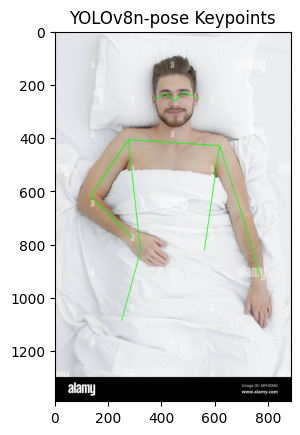

Nose: (452.1568298339844, 262.64239501953125)
Left Eye: (484.989990234375, 230.31431579589844)
Right Eye: (416.2053527832031, 234.2300262451172)
Left Ear: (542.3665771484375, 253.3316650390625)
Right Ear: (375.1407470703125, 257.6206970214844)
Left Shoulder: (618.72216796875, 430.530029296875)
Right Shoulder: (275.2673034667969, 408.958984375)
Left Elbow: (703.0164184570312, 688.7939453125)
Right Elbow: (132.07115173339844, 621.8121337890625)
Left Wrist: (770.5302124023438, 923.4905395507812)
Right Wrist: (292.91632080078125, 776.229736328125)
Left Hip: (561.7315063476562, 823.8536987304688)
Right Hip: (321.4797668457031, 826.8075561523438)
Left Knee: (0.0, 0.0)
Right Knee: (250.43324279785156, 1088.9501953125)
Left Ankle: (0.0, 0.0)
Right Ankle: (0.0, 0.0)


In [33]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model('man1.jpg')  # results list

# Extract coordinates from the results list
keypoints = results[0].keypoints.xy[0]

# Assign values to variables
nose_coords = keypoints[0][0].item(), keypoints[0][1].item()
left_eye_coords = keypoints[1][0].item(), keypoints[1][1].item()
right_eye_coords = keypoints[2][0].item(), keypoints[2][1].item()
left_ear_coords = keypoints[3][0].item(), keypoints[3][1].item()
right_ear_coords = keypoints[4][0].item(), keypoints[4][1].item()
left_shoulder_coords = keypoints[5][0].item(), keypoints[5][1].item()
right_shoulder_coords = keypoints[6][0].item(), keypoints[6][1].item()
left_elbow_coords = keypoints[7][0].item(), keypoints[7][1].item()
right_elbow_coords = keypoints[8][0].item(), keypoints[8][1].item()
left_wrist_coords = keypoints[9][0].item(), keypoints[9][1].item()
right_wrist_coords = keypoints[10][0].item(), keypoints[10][1].item()
left_hip_coords = keypoints[11][0].item(), keypoints[11][1].item()
right_hip_coords = keypoints[12][0].item(), keypoints[12][1].item()
left_knee_coords = keypoints[13][0].item(), keypoints[13][1].item()
right_knee_coords = keypoints[14][0].item(), keypoints[14][1].item()
left_ankle_coords = keypoints[15][0].item(), keypoints[15][1].item()
right_ankle_coords = keypoints[16][0].item(), keypoints[16][1].item()

# Display the image with keypoints and lines
image = cv2.imread('man1.jpg')

# Function to draw a line between two points on the image
def draw_line(img, point1, point2):
    cv2.line(img, point1, point2, (0, 255, 0), 2)

# Draw lines connecting keypoints on the image
lines = [
    (nose_coords, left_eye_coords),
    (nose_coords, right_eye_coords),
    (left_eye_coords, left_ear_coords),
    (right_eye_coords, right_ear_coords),
    (left_shoulder_coords, right_shoulder_coords),
    (left_shoulder_coords, left_elbow_coords),
    (right_shoulder_coords, right_elbow_coords),
    (left_elbow_coords, left_wrist_coords),
    (right_elbow_coords, right_wrist_coords),
    (left_shoulder_coords, left_hip_coords),
    (right_shoulder_coords, right_hip_coords),
    (left_hip_coords, left_knee_coords),
    (right_hip_coords, right_knee_coords),
    (left_knee_coords, left_ankle_coords),
    (right_knee_coords, right_ankle_coords),
]

for line in lines:
    if line[0][0] != 0 and line[0][1] != 0 and line[1][0] != 0 and line[1][1] != 0:
        draw_line(image, tuple(map(int, line[0])), tuple(map(int, line[1])))

# Display the image with matplotlib
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('YOLOv8n-pose Keypoints')
plt.show()

# Print the coordinates
print("Nose:", nose_coords)
print("Left Eye:", left_eye_coords)
print("Right Eye:", right_eye_coords)
print("Left Ear:", left_ear_coords)
print("Right Ear:", right_ear_coords)
print("Left Shoulder:", left_shoulder_coords)
print("Right Shoulder:", right_shoulder_coords)
print("Left Elbow:", left_elbow_coords)
print("Right Elbow:", right_elbow_coords)
print("Left Wrist:", left_wrist_coords)
print("Right Wrist:", right_wrist_coords)
print("Left Hip:", left_hip_coords)
print("Right Hip:", right_hip_coords)
print("Left Knee:", left_knee_coords)
print("Right Knee:", right_knee_coords)
print("Left Ankle:", left_ankle_coords)
print("Right Ankle:", right_ankle_coords)


ESTO VA ACERCANDOSE

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model.predict(source="0", show=True, boxes=True)

# View results
for r in results:
    r.keypoints.xy # print the Keypoints object containing the detected keypoints

# Extract coordinates from the results list
keypoints = results[0].keypoints.xy[0]

# Assign values to variables
nose_coords = keypoints[0][0].item(), keypoints[0][1].item()
left_eye_coords = keypoints[1][0].item(), keypoints[1][1].item()
right_eye_coords = keypoints[2][0].item(), keypoints[2][1].item()
left_ear_coords = keypoints[3][0].item(), keypoints[3][1].item()
right_ear_coords = keypoints[4][0].item(), keypoints[4][1].item()
left_shoulder_coords = keypoints[5][0].item(), keypoints[5][1].item()
right_shoulder_coords = keypoints[6][0].item(), keypoints[6][1].item()
left_elbow_coords = keypoints[7][0].item(), keypoints[7][1].item()
right_elbow_coords = keypoints[8][0].item(), keypoints[8][1].item()
left_wrist_coords = keypoints[9][0].item(), keypoints[9][1].item()
right_wrist_coords = keypoints[10][0].item(), keypoints[10][1].item()
left_hip_coords = keypoints[11][0].item(), keypoints[11][1].item()
right_hip_coords = keypoints[12][0].item(), keypoints[12][1].item()
left_knee_coords = keypoints[13][0].item(), keypoints[13][1].item()
right_knee_coords = keypoints[14][0].item(), keypoints[14][1].item()
left_ankle_coords = keypoints[15][0].item(), keypoints[15][1].item()
right_ankle_coords = keypoints[16][0].item(), keypoints[16][1].item()

# Print the coordinates
print("Nose:", nose_coords)
print("Left Eye:", left_eye_coords)
print("Right Eye:", right_eye_coords)
print("Left Ear:", left_ear_coords)
print("Right Ear:", right_ear_coords)
print("Left Shoulder:", left_shoulder_coords)
print("Right Shoulder:", right_shoulder_coords)
print("Left Elbow:", left_elbow_coords)
print("Right Elbow:", right_elbow_coords)
print("Left Wrist:", left_wrist_coords)
print("Right Wrist:", right_wrist_coords)
print("Left Hip:", left_hip_coords)
print("Right Hip:", right_hip_coords)
print("Left Knee:", left_knee_coords)
print("Right Knee:", right_knee_coords)
print("Left Ankle:", left_ankle_coords)
print("Right Ankle:", right_ankle_coords)


right now

In [ ]:

from ultralytics import YOLO
import cv2

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (in this case, camera index 0)
cap = cv2.VideoCapture(0)

# Initialize a variable to control the while loop
running = True

while running:
    # Run inference on the live camera feed
    results = model.predict(source=0, show=True, boxes=True)

    # View results
    for r in results:
        keypoints = r.keypoints.xy[0]

        # Assign values to variables
        nose_coords = keypoints[0][0].item(), keypoints[0][1].item()
        left_eye_coords = keypoints[1][0].item(), keypoints[1][1].item()
        right_eye_coords = keypoints[2][0].item(), keypoints[2][1].item()
        left_ear_coords = keypoints[3][0].item(), keypoints[3][1].item()
        right_ear_coords = keypoints[4][0].item(), keypoints[4][1].item()
        left_shoulder_coords = keypoints[5][0].item(), keypoints[5][1].item()
        right_shoulder_coords = keypoints[6][0].item(), keypoints[6][1].item()
        left_elbow_coords = keypoints[7][0].item(), keypoints[7][1].item()
        right_elbow_coords = keypoints[8][0].item(), keypoints[8][1].item()
        left_wrist_coords = keypoints[9][0].item(), keypoints[9][1].item()
        right_wrist_coords = keypoints[10][0].item(), keypoints[10][1].item()
        left_hip_coords = keypoints[11][0].item(), keypoints[11][1].item()
        right_hip_coords = keypoints[12][0].item(), keypoints[12][1].item()
        left_knee_coords = keypoints[13][0].item(), keypoints[13][1].item()
        right_knee_coords = keypoints[14][0].item(), keypoints[14][1].item()
        left_ankle_coords = keypoints[15][0].item(), keypoints[15][1].item()
        right_ankle_coords = keypoints[16][0].item(), keypoints[16][1].item()

        # Print the coordinates (you can replace this with any other desired processing)
        print("Nose:", nose_coords)
        print("Left Eye:", left_eye_coords)
        print("Right Eye:", right_eye_coords)
        print("Left Ear:", left_ear_coords)
        print("Right Ear:", right_ear_coords)
        print("Left Shoulder:", left_shoulder_coords)
        print("Right Shoulder:", right_shoulder_coords)
        print("Left Elbow:", left_elbow_coords)
        print("Right Elbow:", right_elbow_coords)
        print("Left Wrist:", left_wrist_coords)
        print("Right Wrist:", right_wrist_coords)
        print("Left Hip:", left_hip_coords)
        print("Right Hip:", right_hip_coords)
        print("Left Knee:", left_knee_coords)
        print("Right Knee:", right_knee_coords)
        print("Left Ankle:", left_ankle_coords)
        print("Right Ankle:", right_ankle_coords)


    # Check if the 'q' key is pressed to exit the loop
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        running = False

# Release the camera and close all windows
cap.release()
cv2.destroyAllWindows()



In [83]:
from ultralytics import YOLO
import cv2

# Load the YOLOv8 model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (in this case, camera index 0)
cap = cv2.VideoCapture(0)

# Check if the camera is opened successfully
if not cap.isOpened():
    print("Error: Could not open camera.")
    exit()

try:
    # Loop through the video frames
    while True:
        # Read a frame from the video
        success, frame = cap.read()

        if success:
            # Run YOLOv8 inference on the frame
            results = model.predict(source=frame, show_boxes=True)

            # Display the annotated frame if it has a valid size
            annotated_frame = results[0].show()
            if annotated_frame.shape[0] > 0 and annotated_frame.shape[1] > 0:
                cv2.imshow("YOLOv8 Inference", annotated_frame)

            # Break the loop if 'q' is pressed
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break
        else:
            # Break the loop if the end of the video is reached
            break

finally:
    # Release the video capture object and close the display window
    cap.release()
    cv2.destroyAllWindows()



0: 384x640 1 person, 319.9ms
Speed: 8.0ms preprocess, 319.9ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)


AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
import cv2
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (in this case, camera index 0)
cap = cv2.VideoCapture(0)

while True:
    # Read a frame from the camera
    ret, frame = cap.read()
    
    if not ret:
        print("Failed to capture frame. Exiting...")
        break

    # Run inference on the current frame
    results = model.predict(source=frame, show=False, boxes=True)

    # Extract coordinates from the results list
    keypoints = results[0].keypoints.xy[0]

    # Assign values to variables
    nose_coords = keypoints[0][0].item(), keypoints[0][1].item()
    left_eye_coords = keypoints[1][0].item(), keypoints[1][1].item()
    right_eye_coords = keypoints[2][0].item(), keypoints[2][1].item()
    left_ear_coords = keypoints[3][0].item(), keypoints[3][1].item()
    right_ear_coords = keypoints[4][0].item(), keypoints[4][1].item()
    left_shoulder_coords = keypoints[5][0].item(), keypoints[5][1].item()
    right_shoulder_coords = keypoints[6][0].item(), keypoints[6][1].item()
    left_elbow_coords = keypoints[7][0].item(), keypoints[7][1].item()
    right_elbow_coords = keypoints[8][0].item(), keypoints[8][1].item()
    left_wrist_coords = keypoints[9][0].item(), keypoints[9][1].item()
    right_wrist_coords = keypoints[10][0].item(), keypoints[10][1].item()
    left_hip_coords = keypoints[11][0].item(), keypoints[11][1].item()
    right_hip_coords = keypoints[12][0].item(), keypoints[12][1].item()
    left_knee_coords = keypoints[13][0].item(), keypoints[13][1].item()
    right_knee_coords = keypoints[14][0].item(), keypoints[14][1].item()
    left_ankle_coords = keypoints[15][0].item(), keypoints[15][1].item()
    right_ankle_coords = keypoints[16][0].item(), keypoints[16][1].item()

    # Display the frame with keypoints and lines (if needed)
    frame_with_lines = frame.copy()

    # Function to draw a line between two points on the image
    def draw_line(img, point1, point2):
        cv2.line(img, point1, point2, (0, 255, 0), 2)

    # Draw lines connecting keypoints on the image
    lines = [
        (nose_coords, left_eye_coords),
        (nose_coords, right_eye_coords),
        (left_eye_coords, left_ear_coords),
        (right_eye_coords, right_ear_coords),
        (left_shoulder_coords, right_shoulder_coords),
        (left_shoulder_coords, left_elbow_coords),
        (right_shoulder_coords, right_elbow_coords),
        (left_elbow_coords, left_wrist_coords),
        (right_elbow_coords, right_wrist_coords),
        (left_shoulder_coords, left_hip_coords),
        (right_shoulder_coords, right_hip_coords),
        (left_hip_coords, left_knee_coords),
        (right_hip_coords, right_knee_coords),
        (left_knee_coords, left_ankle_coords),
        (right_knee_coords, right_ankle_coords),
    ]

    for line in lines:
        if line[0][0] != 0 and line[0][1] != 0 and line[1][0] != 0 and line[1][1] != 0:
            draw_line(frame_with_lines, tuple(map(int, line[0])), tuple(map(int, line[1])))

    # Display the frame with matplotlib
    cv2.imshow('YOLOv8n-pose Live Inference', frame_with_lines)

    # Exit the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close all windows
cap.release()
cv2.destroyAllWindows()


THISSS


In [27]:
from ultralytics import YOLO
import cv2

# Start webcam
cap = cv2.VideoCapture(1)
cap.set(3, 640)
cap.set(4, 480)

# Model
model = YOLO("yolov8n-pose.pt")

# Permanent boundary box for bed
bed_box_coords = (bed_coords)

while True:
    success, img = cap.read()

    # Get predictions from the model
    results = model.predict(source=img)

    # Initialize status and status_color
    status = "No person detected"
    status_color = (0, 0, 0)  # Black

    # Draw the permanent boundary box for the bed
    bed_color = (255, 255, 255)
    bed_thickness = 2
    cv2.rectangle(img, (bed_box_coords[0], bed_box_coords[1]), (bed_box_coords[2], bed_box_coords[3]), bed_color, bed_thickness)

    # Mark the boundary box of the bed with the word "Bed"
    bed_text = "Bed"
    bed_text_color = (255, 255, 255)  # White text
    bed_text_font = cv2.FONT_HERSHEY_SIMPLEX
    bed_text_scale = 1
    bed_text_thickness = 2

    # Get the size of the text box
    (text_width, text_height), baseline = cv2.getTextSize(bed_text, bed_text_font, bed_text_scale, bed_text_thickness)

    # Calculate the position to the right of the boundary box
    bed_text_x = bed_box_coords[2] + 10  # Adjust the offset as needed
    bed_text_y = (bed_box_coords[1] + bed_box_coords[3] - text_height) // 2

    # Draw the outlined text
    bed_text_border_thickness = 5
    cv2.putText(img, bed_text, (bed_text_x, bed_text_y), bed_text_font, bed_text_scale, (0, 0, 0), bed_text_border_thickness + 2, cv2.LINE_AA)
    cv2.putText(img, bed_text, (bed_text_x, bed_text_y), bed_text_font, bed_text_scale, bed_text_color, bed_text_thickness, cv2.LINE_AA)

    # Check the position of each keypoint relative to the bed boundary box
    all_keypoints_inside = True
    for result in results.xyxy[0]:
        if result.keypoints is not None:
            # Draw pose estimation skeleton with keypoints and connections
            img = result.show()
            
            keypoints = result.keypoints.xy[0]
            for kp in keypoints:
                if kp[2] > 0:  # Check if the keypoint is visible
                    cv2.circle(img, tuple(kp[:2].astype(int)), 5, (0, 255, 0), -1)

                if not (bed_box_coords[0] <= kp[0] <= bed_box_coords[2] and bed_box_coords[1] <= kp[1] <= bed_box_coords[3]):
                    all_keypoints_inside = False

    if all_keypoints_inside:
        status = "Person is in bed"
        status_color = (0, 255, 0)  # Green
    else:
        any_keypoint_outside = any(
            not (bed_box_coords[0] <= kp[0] <= bed_box_coords[2] and bed_box_coords[1] <= kp[1] <= bed_box_coords[3])
            for result in results.xyxy[0]
            if result.keypoints is not None
            for kp in result.keypoints.xy[0]
        )

        if any_keypoint_outside:
            status = "Person fell out of bed"
            status_color = (0, 165, 255)  # Orange
        else:
            status = "Person is out of bed"
            status_color = (0, 0, 255)  # Red

    # Display the status with enhanced styling in the bottom left corner
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.2
    font_thickness = 2
    cv2.putText(img, f"{status}", (10, 480 - 10), font, font_scale, (255, 255, 255), 5, cv2.LINE_AA)
    cv2.putText(img, f"{status}", (10, 480 - 10), font, font_scale, status_color, font_thickness, cv2.LINE_AA)

    cv2.imshow('Webcam', img)
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



0: 480x640 1 person, 268.1ms
Speed: 6.1ms preprocess, 268.1ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


AttributeError: 'list' object has no attribute 'xyxy'

In [116]:


# Extract coordinates from the results list
keypoints = results[0].keypoints.xy[0]

# Assign values to variables
nose_coords = keypoints[0][0].item(), keypoints[0][1].item()
left_eye_coords = keypoints[1][0].item(), keypoints[1][1].item()
right_eye_coords = keypoints[2][0].item(), keypoints[2][1].item()
left_ear_coords = keypoints[3][0].item(), keypoints[3][1].item()
right_ear_coords = keypoints[4][0].item(), keypoints[4][1].item()
left_shoulder_coords = keypoints[5][0].item(), keypoints[5][1].item()
right_shoulder_coords = keypoints[6][0].item(), keypoints[6][1].item()
left_elbow_coords = keypoints[7][0].item(), keypoints[7][1].item()
right_elbow_coords = keypoints[8][0].item(), keypoints[8][1].item()
left_wrist_coords = keypoints[9][0].item(), keypoints[9][1].item()
right_wrist_coords = keypoints[10][0].item(), keypoints[10][1].item()
left_hip_coords = keypoints[11][0].item(), keypoints[11][1].item()
right_hip_coords = keypoints[12][0].item(), keypoints[12][1].item()
left_knee_coords = keypoints[13][0].item(), keypoints[13][1].item()
right_knee_coords = keypoints[14][0].item(), keypoints[14][1].item()
left_ankle_coords = keypoints[15][0].item(), keypoints[15][1].item()
right_ankle_coords = keypoints[16][0].item(), keypoints[16][1].item()

# Print the coordinates
print("Nose:", nose_coords)
print("Left Eye:", left_eye_coords)
print("Right Eye:", right_eye_coords)
print("Left Ear:", left_ear_coords)
print("Right Ear:", right_ear_coords)
print("Left Shoulder:", left_shoulder_coords)
print("Right Shoulder:", right_shoulder_coords)
print("Left Elbow:", left_elbow_coords)
print("Right Elbow:", right_elbow_coords)
print("Left Wrist:", left_wrist_coords)
print("Right Wrist:", right_wrist_coords)
print("Left Hip:", left_hip_coords)
print("Right Hip:", right_hip_coords)
print("Left Knee:", left_knee_coords)
print("Right Knee:", right_knee_coords)
print("Left Ankle:", left_ankle_coords)
print("Right Ankle:", right_ankle_coords)


Nose: (452.1568298339844, 262.64239501953125)
Left Eye: (484.989990234375, 230.31431579589844)
Right Eye: (416.2053527832031, 234.2300262451172)
Left Ear: (542.3665771484375, 253.3316650390625)
Right Ear: (375.1407470703125, 257.6206970214844)
Left Shoulder: (618.72216796875, 430.530029296875)
Right Shoulder: (275.2673034667969, 408.958984375)
Left Elbow: (703.0164184570312, 688.7939453125)
Right Elbow: (132.07115173339844, 621.8121337890625)
Left Wrist: (770.5302124023438, 923.4905395507812)
Right Wrist: (292.91632080078125, 776.229736328125)
Left Hip: (561.7315063476562, 823.8536987304688)
Right Hip: (321.4797668457031, 826.8075561523438)
Left Knee: (0.0, 0.0)
Right Knee: (250.43324279785156, 1088.9501953125)
Left Ankle: (0.0, 0.0)
Right Ankle: (0.0, 0.0)


In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Run live view
#model.predict(source="0", show=True, boxes=True)

# Initialize variables for keypoints
nose_coords = (0, 0)
left_eye_coords = (0, 0)
right_eye_coords = (0, 0)
left_ear_coords = (0, 0)
right_ear_coords = (0, 0)
left_shoulder_coords = (0, 0)
right_shoulder_coords = (0, 0)
left_elbow_coords = (0, 0)
right_elbow_coords = (0, 0)
left_wrist_coords = (0, 0)
right_wrist_coords = (0, 0)
left_hip_coords = (0, 0)
right_hip_coords = (0, 0)
left_knee_coords = (0, 0)
right_knee_coords = (0, 0)
left_ankle_coords = (0, 0)
right_ankle_coords = (0, 0)

# Function to update keypoints variables
def update_keypoints(results):
    if results and results.pred[0] is not None:
        keypoints = results.pred[0].keypoints.xy[0]
        # Update variables
        global nose_coords, left_eye_coords, right_eye_coords, left_ear_coords, right_ear_coords
        global left_shoulder_coords, right_shoulder_coords, left_elbow_coords, right_elbow_coords
        global left_wrist_coords, right_wrist_coords, left_hip_coords, right_hip_coords
        global left_knee_coords, right_knee_coords, left_ankle_coords, right_ankle_coords

        nose_coords = keypoints[0][0].item(), keypoints[0][1].item()
        left_eye_coords = keypoints[1][0].item(), keypoints[1][1].item()
        right_eye_coords = keypoints[2][0].item(), keypoints[2][1].item()
        left_ear_coords = keypoints[3][0].item(), keypoints[3][1].item()
        right_ear_coords = keypoints[4][0].item(), keypoints[4][1].item()
        left_shoulder_coords = keypoints[5][0].item(), keypoints[5][1].item()
        right_shoulder_coords = keypoints[6][0].item(), keypoints[6][1].item()
        left_elbow_coords = keypoints[7][0].item(), keypoints[7][1].item()
        right_elbow_coords = keypoints[8][0].item(), keypoints[8][1].item()
        left_wrist_coords = keypoints[9][0].item(), keypoints[9][1].item()
        right_wrist_coords = keypoints[10][0].item(), keypoints[10][1].item()
        left_hip_coords = keypoints[11][0].item(), keypoints[11][1].item()
        right_hip_coords = keypoints[12][0].item(), keypoints[12][1].item()
        left_knee_coords = keypoints[13][0].item(), keypoints[13][1].item()
        right_knee_coords = keypoints[14][0].item(), keypoints[14][1].item()
        left_ankle_coords = keypoints[15][0].item(), keypoints[15][1].item()
        right_ankle_coords = keypoints[16][0].item(), keypoints[16][1].item()

# Run live view with continuous updates
model.predict(source="0", show=True, boxes=True, on_result=update_keypoints)


In [4]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model('man1.jpg')  # results list

# View results
for r in results:
    r.keypoints.xy  # print the Keypoints object containing the detected keypoints

# Extract coordinates from the results list
keypoints = results[0].keypoints.xy[0]

# Assign values to variables
nose_coords = keypoints[0][0].item(), keypoints[0][1].item()
left_eye_coords = keypoints[1][0].item(), keypoints[1][1].item()
right_eye_coords = keypoints[2][0].item(), keypoints[2][1].item()
left_ear_coords = keypoints[3][0].item(), keypoints[3][1].item()
right_ear_coords = keypoints[4][0].item(), keypoints[4][1].item()
left_shoulder_coords = keypoints[5][0].item(), keypoints[5][1].item()
right_shoulder_coords = keypoints[6][0].item(), keypoints[6][1].item()
left_elbow_coords = keypoints[7][0].item(), keypoints[7][1].item()
right_elbow_coords = keypoints[8][0].item(), keypoints[8][1].item()
left_wrist_coords = keypoints[9][0].item(), keypoints[9][1].item()
right_wrist_coords = keypoints[10][0].item(), keypoints[10][1].item()
left_hip_coords = keypoints[11][0].item(), keypoints[11][1].item()
right_hip_coords = keypoints[12][0].item(), keypoints[12][1].item()
left_knee_coords = keypoints[13][0].item(), keypoints[13][1].item()
right_knee_coords = keypoints[14][0].item(), keypoints[14][1].item()
left_ankle_coords = keypoints[15][0].item(), keypoints[15][1].item()
right_ankle_coords = keypoints[16][0].item(), keypoints[16][1].item()


image 1/1 /Users/emibetroldan/prueba/YOLOv6/man1.jpg: 640x416 1 person, 132.2ms
Speed: 4.3ms preprocess, 132.2ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 416)


In [125]:
import cv2

# Load the image
image = cv2.imread('man1.jpg')

# Coordinates
x, y = (452.1568298339844, 262.64239501953125)

# Draw a dot on the image at the specified coordinates
cv2.circle(image, (int(x), int(y)), 5, (0, 255, 0), -1)  # Assuming green color (BGR)

# Display the image
cv2.imshow('Image with Dot', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [12]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model('man.jpg')  # results list

# Map class indices to class names (assuming there are 17 keypoints)
class_names = ["keypoint_1", "keypoint_2", ..., "keypoint_17"]

# View results
for r in results:
    keypoints = r.keypoints.data[0]

    for i in range(keypoints.shape[0]):
        x, y, confidence = keypoints[i, :3].tolist()

        if confidence > 0.5:  # Assuming 0.5 as a threshold for confidence
            class_index = int(keypoints[i, 2].item())
            class_name = class_names[class_index]

            print(f"Class: {class_name}, Confidence: {confidence:.4f}, Coordinates: ({x:.2f}, {y:.2f})")



image 1/1 /Users/emibetroldan/prueba/YOLOv6/bus.jpg: 640x480 4 persons, 206.0ms
Speed: 6.1ms preprocess, 206.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)
Class: keypoint_1, Confidence: 0.9803, Coordinates: (143.37, 444.84)
Class: keypoint_1, Confidence: 0.9045, Coordinates: (148.27, 435.67)
Class: keypoint_1, Confidence: 0.9619, Coordinates: (132.06, 436.29)
Class: keypoint_1, Confidence: 0.8145, Coordinates: (104.57, 443.18)
Class: keypoint_1, Confidence: 0.9860, Coordinates: (162.94, 495.44)
Class: keypoint_1, Confidence: 0.9896, Coordinates: (87.64, 497.77)
Class: keypoint_1, Confidence: 0.9528, Coordinates: (191.12, 564.78)
Class: keypoint_1, Confidence: 0.9695, Coordinates: (112.46, 567.08)
Class: keypoint_1, Confidence: 0.9332, Coordinates: (161.60, 538.21)
Class: keypoint_1, Confidence: 0.9532, Coordinates: (154.78, 544.96)
Class: keypoint_1, Confidence: 0.9936, Coordinates: (155.64, 638.87)
Class: keypoint_1, Confidence: 0.9943, Coordinates: (97.05, 640

In [48]:
from ultralytics import YOLO

# Load the model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model("bus.jpg", show=True)

# Iterate over the results list (even if there's only one image)
for result in results:
    # Access the keypoints from the result
    keypoints = result.keypoints.xyn.cpu().numpy()
    print(keypoints)


image 1/1 /Users/emibetroldan/prueba/YOLOv6/bus.jpg: 640x480 4 persons, 179.9ms
Speed: 4.7ms preprocess, 179.9ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 480)
[[[      0.177     0.41189]
  [    0.18305      0.4034]
  [    0.16304     0.40397]
  [          0           0]
  [     0.1291     0.41035]
  [    0.20116     0.45874]
  [     0.1082      0.4609]
  [    0.23595     0.52295]
  [    0.13884     0.52508]
  [    0.19951     0.49835]
  [    0.19109     0.50459]
  [    0.19215     0.59155]
  [    0.11981     0.59337]
  [     0.2195     0.69523]
  [     0.1115     0.69979]
  [    0.23757     0.79331]
  [   0.099484     0.79713]]

 [[          0           0]
  [          0           0]
  [          0           0]
  [          0           0]
  [          0           0]
  [    0.99809     0.44967]
  [          0           0]
  [    0.97421     0.52331]
  [          0           0]
  [    0.92826     0.52484]
  [          0           0]
  [    0.99671      0.5948]
  [    

In [6]:
from ultralytics import YOLO

# Load the model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model("bus.jpg", show=True)

# Iterate over the results list (even if there's only one image)
for result in results:
    # Access the keypoints from the result
    keypoints = result.keypoints.xyn.cpu().numpy()

    # Define class names for keypoints
    keypoint_class_names = [
        'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
        'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
        'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
        'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
    ]

    # Iterate over each keypoint
    for idx, point in enumerate(keypoints[0]):
        # Check if the keypoint is detected
        if point[0] > 0:
            # Extract class, x, and y coordinates
            keypoint_class = keypoint_class_names[idx]
            x, y = point

            # Print the result
            print(f"{keypoint_class}, {x}, {y}")


            from ultralytics import YOLO





image 1/1 /Users/emibetroldan/prueba/YOLOv6/bus.jpg: 640x480 4 persons, 85.8ms
Speed: 2.7ms preprocess, 85.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
nose, 0.1770004779100418, 0.4118875563144684
left_eye, 0.18304936587810516, 0.4034019410610199
right_eye, 0.16303525865077972, 0.403968870639801
right_ear, 0.12909650802612305, 0.4103500247001648
left_shoulder, 0.20116248726844788, 0.4587383568286896
right_shoulder, 0.10819841921329498, 0.46089690923690796
left_elbow, 0.23595380783081055, 0.5229483842849731
right_elbow, 0.13884085416793823, 0.5250776410102844
left_wrist, 0.1995103508234024, 0.4983464479446411
right_wrist, 0.19108901917934418, 0.5045914053916931
left_hip, 0.19215349853038788, 0.5915467143058777
right_hip, 0.1198107972741127, 0.5933690071105957
left_knee, 0.21950383484363556, 0.6952286958694458
right_knee, 0.11149685084819794, 0.6997884511947632
left_ankle, 0.2375679910182953, 0.7933104038238525
right_ankle, 0.09948360919952393, 0.7971277832984924

In [45]:
from ultralytics import YOLO

# Load the YOLO pose model
model = YOLO('yolov8n-pose.pt')

# Perform prediction on an image
results = model("bus.jpg", show=True)

# Check if the keypoints attribute is present in the results
if hasattr(results[0], 'keypoints'):
    # Access the keypoints for the first detected object
    keypoints = results[0].keypoints
    # Convert keypoints to numpy array and access the keypoints for the first detected object
    keypoints_numpy = keypoints.xyn.cpu().numpy()[0]
    print(keypoints_numpy)
else:
    print("No keypoints attribute found in the results.")


image 1/1 /Users/emibetroldan/prueba/YOLOv6/bus.jpg: 640x480 4 persons, 111.8ms
Speed: 6.3ms preprocess, 111.8ms inference, 13.1ms postprocess per image at shape (1, 3, 640, 480)
[[      0.177     0.41189]
 [    0.18305      0.4034]
 [    0.16304     0.40397]
 [          0           0]
 [     0.1291     0.41035]
 [    0.20116     0.45874]
 [     0.1082      0.4609]
 [    0.23595     0.52295]
 [    0.13884     0.52508]
 [    0.19951     0.49835]
 [    0.19109     0.50459]
 [    0.19215     0.59155]
 [    0.11981     0.59337]
 [     0.2195     0.69523]
 [     0.1115     0.69979]
 [    0.23757     0.79331]
 [   0.099484     0.79713]]


In [49]:
# View results
for r in results:
    keypoints = r.keypoints.data[0]

    for i in range(keypoints.shape[0]):
        x, y, confidence = keypoints[i, :3].tolist()

        if confidence > 0.5:  # Assuming 0.5 as a threshold for confidence
            class_index = int(keypoints[i, 0].item())  # Use the correct index (change from 2 to 0)
            class_name = class_names[class_index]

            print(f"Class: {class_name}, Confidence: {confidence:.4f}, Coordinates: ({x:.2f}, {y:.2f})")


IndexError: list index out of range

In [136]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Run inference on an image
results = model('bus.jpg')  # results list

# Map class indices to class names for body parts
class_names = [
    "nose", "leftEye", "rightEye", "leftEar", "rightEar",
    "leftShoulder", "rightShoulder", "leftElbow", "rightElbow",
    "leftWrist", "rightWrist", "leftHip", "rightHip",
    "leftKnee", "rightKnee", "leftAnkle", "rightAnkle"
]

# View results
for r in results:
    keypoints = r.keypoints.data[0]

    for i in range(keypoints.shape[0]):
        x, y, confidence = keypoints[i, :3].tolist()

        if confidence > 0.5:  # Assuming 0.5 as a threshold for confidence
            class_index = int(keypoints[i, 2].item())  # Use the correct index
            class_name = class_names[class_index]

            print(f"Class: {class_name}, Confidence: {confidence:.4f}, Coordinates: ({x:.2f}, {y:.2f})")


image 1/1 /Users/emibetroldan/prueba/YOLOv6/bus.jpg: 640x480 4 persons, 163.6ms
Speed: 8.1ms preprocess, 163.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)
Class: nose, Confidence: 0.9803, Coordinates: (143.37, 444.84)
Class: nose, Confidence: 0.9045, Coordinates: (148.27, 435.67)
Class: nose, Confidence: 0.9619, Coordinates: (132.06, 436.29)
Class: nose, Confidence: 0.8145, Coordinates: (104.57, 443.18)
Class: nose, Confidence: 0.9860, Coordinates: (162.94, 495.44)
Class: nose, Confidence: 0.9896, Coordinates: (87.64, 497.77)
Class: nose, Confidence: 0.9528, Coordinates: (191.12, 564.78)
Class: nose, Confidence: 0.9695, Coordinates: (112.46, 567.08)
Class: nose, Confidence: 0.9332, Coordinates: (161.60, 538.21)
Class: nose, Confidence: 0.9532, Coordinates: (154.78, 544.96)
Class: nose, Confidence: 0.9936, Coordinates: (155.64, 638.87)
Class: nose, Confidence: 0.9943, Coordinates: (97.05, 640.84)
Class: nose, Confidence: 0.9881, Coordinates: (177.80, 750.85)
Clas

In [ ]:
import cv2
from ultralytics import YOLO

# Load a pretrained YOLOv8n-pose Pose model
model = YOLO('yolov8n-pose.pt')

# Map class indices to class names for body parts
class_names = [
    "nose", "leftEye", "rightEye", "leftEar", "rightEar",
    "leftShoulder", "rightShoulder", "leftElbow", "rightElbow",
    "leftWrist", "rightWrist", "leftHip", "rightHip",
    "leftKnee", "rightKnee", "leftAnkle", "rightAnkle"
]

# Open a connection to the camera (0 is usually the default camera)
cap = cv2.VideoCapture(0)

while True:
    # Read a frame from the camera
    ret, frame = cap.read()
    if not ret:
        break

    # Run inference on the current frame
    results = model(frame)

    # Process and display the results
    for r in results:
        keypoints = r.keypoints.data[0]

        for i in range(keypoints.shape[0]):
            x, y, confidence = keypoints[i, :3].tolist()

            if confidence > 0.5:  # Assuming 0.5 as a threshold for confidence
                class_index = int(keypoints[i, 2].item())
                class_name = class_names[class_index]

                # Draw a point on the frame at the detected keypoint
                cv2.circle(frame, (int(x), int(y)), 5, (0, 255, 0), -1)

                # Display the class name, confidence, and coordinates
                text = f"{class_name}: {confidence:.4f} ({x:.2f}, {y:.2f})"
                cv2.putText(frame, text, (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    # Display the frame with keypoints
    cv2.imshow('Pose Estimation', frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close the window
cap.release()
cv2.destroyAllWindows()


In [17]:
from ultralytics import YOLO

# Load a model
model = YOLO('yolov8n-pose.pt')

# Predict with the model
results = model('bus.jpg') 

# Extract keypoints from the first result in the list
result_keypoints = results[0].keypoints.xy[0]  # Extracting keypoints

# Convert the keypoints to a NumPy array
result_keypoints = result_keypoints.cpu().numpy()

print(result_keypoints)



image 1/1 /Users/emibetroldan/prueba/YOLOv6/bus.jpg: 640x480 4 persons, 202.3ms
Speed: 6.4ms preprocess, 202.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
[[     143.37      444.84]
 [     148.27      435.67]
 [     132.06      436.29]
 [          0           0]
 [     104.57      443.18]
 [     162.94      495.44]
 [     87.641      497.77]
 [     191.12      564.78]
 [     112.46      567.08]
 [      161.6      538.21]
 [     154.78      544.96]
 [     155.64      638.87]
 [     97.047      640.84]
 [      177.8      750.85]
 [     90.312      755.77]
 [     192.43      856.78]
 [     80.582       860.9]]


In [18]:
from pydantic import BaseModel

class GetKeypoint(BaseModel):
    NOSE:           int = 0
    LEFT_EYE:       int = 1
    RIGHT_EYE:      int = 2
    LEFT_EAR:       int = 3
    RIGHT_EAR:      int = 4
    LEFT_SHOULDER:  int = 5
    RIGHT_SHOULDER: int = 6
    LEFT_ELBOW:     int = 7
    RIGHT_ELBOW:    int = 8
    LEFT_WRIST:     int = 9
    RIGHT_WRIST:    int = 10
    LEFT_HIP:       int = 11
    RIGHT_HIP:      int = 12
    LEFT_KNEE:      int = 13
    RIGHT_KNEE:     int = 14
    LEFT_ANKLE:     int = 15
    RIGHT_ANKLE:    int = 16

get_keypoint = GetKeypoint()
nose_x, nose_y = result_keypoints[get_keypoint.NOSE]
left_eye_x, left_eye_y = result_keypoints[get_keypoint.LEFT_EYE]
right_eye_x, right_eye_y = result_keypoints[get_keypoint.RIGHT_EYE]
left_ear_x, left_ear_y = result_keypoints[get_keypoint.LEFT_EAR]
right_ear_x, right_ear_y = result_keypoints[get_keypoint.RIGHT_EAR]
left_shoulder_x, left_shoulder_y = result_keypoints[get_keypoint.LEFT_SHOULDER]
right_shoulder_x, right_shoulder_y = result_keypoints[get_keypoint.RIGHT_SHOULDER]
left_elbow_x, left_elbow_y = result_keypoints[get_keypoint.LEFT_ELBOW]
right_elbow_x, right_elbow_y = result_keypoints[get_keypoint.RIGHT_ELBOW]
left_wrist_x, left_wrist_y = result_keypoints[get_keypoint.LEFT_WRIST]
right_wrist_x, right_wrist_y = result_keypoints[get_keypoint.RIGHT_WRIST]
left_hip_x, left_hip_y = result_keypoints[get_keypoint.LEFT_HIP]
right_hip_x, right_hip_y = result_keypoints[get_keypoint.RIGHT_HIP]
left_knee_x, left_knee_y = result_keypoints[get_keypoint.LEFT_KNEE]
right_knee_x, right_knee_y = result_keypoints[get_keypoint.RIGHT_KNEE]
left_ankle_x, left_ankle_y = result_keypoints[get_keypoint.LEFT_ANKLE]
right_ankle_x, right_ankle_y = result_keypoints[get_keypoint.RIGHT_ANKLE]

nose_coords = nose_x, nose_y
left_eye_coords = left_eye_x, left_eye_y
right_eye_coords = right_eye_x, right_eye_y
left_ear_coords = left_ear_x, left_ear_y
right_ear_coords = right_ear_x, right_ear_y
left_shoulder_coords = left_shoulder_x, left_shoulder_y
right_shoulder_coords = right_shoulder_x, right_shoulder_y
left_elbow_coords = left_elbow_x, left_elbow_y
right_elbow_coords = right_elbow_x, right_elbow_y
left_wrist_coords = left_wrist_x, left_wrist_y
right_wrist_coords = right_wrist_x, right_wrist_y
left_hip_coords = left_hip_x, left_hip_y
right_hip_coords = right_hip_x, right_hip_y
left_knee_coords = left_knee_x, left_knee_y
right_knee_coords = right_knee_x, right_knee_y
left_ankle_coords = left_ankle_x, left_ankle_y
right_ankle_coords = right_ankle_x, right_ankle_y


In [1]:
import cv2

# Load the image
image = cv2.imread('bus.jpg')

# Coordinates
x, y = (1230.9009, 436.58093)

# Draw a dot on the image at the specified coordinates
cv2.circle(image, (int(x), int(y)), 5, (0, 255, 0), -1)  # Assuming green color (BGR)

# Display the image
cv2.imshow('Image with Dot', image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [137]:
from ultralytics import YOLO

# Load a model
model = YOLO('yolov8n-pose.pt')

# Predict with the model
results = model('bus.jpg') 

# Extract keypoints from the first result in the list
result_keypoints = results[0].keypoints.xy[0]  # Extracting keypoints

# Convert the keypoints to a NumPy array
result_keypoints = result_keypoints.cpu().numpy()

from pydantic import BaseModel

class GetKeypoint(BaseModel):
    NOSE:           int = 0
    LEFT_EYE:       int = 1
    RIGHT_EYE:      int = 2
    LEFT_EAR:       int = 3
    RIGHT_EAR:      int = 4
    LEFT_SHOULDER:  int = 5
    RIGHT_SHOULDER: int = 6
    LEFT_ELBOW:     int = 7
    RIGHT_ELBOW:    int = 8
    LEFT_WRIST:     int = 9
    RIGHT_WRIST:    int = 10
    LEFT_HIP:       int = 11
    RIGHT_HIP:      int = 12
    LEFT_KNEE:      int = 13
    RIGHT_KNEE:     int = 14
    LEFT_ANKLE:     int = 15
    RIGHT_ANKLE:    int = 16

get_keypoint = GetKeypoint()
nose_x, nose_y = result_keypoints[get_keypoint.NOSE]
left_eye_x, left_eye_y = result_keypoints[get_keypoint.LEFT_EYE]
right_eye_x, right_eye_y = result_keypoints[get_keypoint.RIGHT_EYE]
left_ear_x, left_ear_y = result_keypoints[get_keypoint.LEFT_EAR]
right_ear_x, right_ear_y = result_keypoints[get_keypoint.RIGHT_EAR]
left_shoulder_x, left_shoulder_y = result_keypoints[get_keypoint.LEFT_SHOULDER]
right_shoulder_x, right_shoulder_y = result_keypoints[get_keypoint.RIGHT_SHOULDER]
left_elbow_x, left_elbow_y = result_keypoints[get_keypoint.LEFT_ELBOW]
right_elbow_x, right_elbow_y = result_keypoints[get_keypoint.RIGHT_ELBOW]
left_wrist_x, left_wrist_y = result_keypoints[get_keypoint.LEFT_WRIST]
right_wrist_x, right_wrist_y = result_keypoints[get_keypoint.RIGHT_WRIST]
left_hip_x, left_hip_y = result_keypoints[get_keypoint.LEFT_HIP]
right_hip_x, right_hip_y = result_keypoints[get_keypoint.RIGHT_HIP]
left_knee_x, left_knee_y = result_keypoints[get_keypoint.LEFT_KNEE]
right_knee_x, right_knee_y = result_keypoints[get_keypoint.RIGHT_KNEE]
left_ankle_x, left_ankle_y = result_keypoints[get_keypoint.LEFT_ANKLE]
right_ankle_x, right_ankle_y = result_keypoints[get_keypoint.RIGHT_ANKLE]

nose_coords = nose_x, nose_y
left_eye_coords = left_eye_x, left_eye_y
right_eye_coords = right_eye_x, right_eye_y
left_ear_coords = left_ear_x, left_ear_y
right_ear_coords = right_ear_x, right_ear_y
left_shoulder_coords = left_shoulder_x, left_shoulder_y
right_shoulder_coords = right_shoulder_x, right_shoulder_y
left_elbow_coords = left_elbow_x, left_elbow_y
right_elbow_coords = right_elbow_x, right_elbow_y
left_wrist_coords = left_wrist_x, left_wrist_y
right_wrist_coords = right_wrist_x, right_wrist_y
left_hip_coords = left_hip_x, left_hip_y
right_hip_coords = right_hip_x, right_hip_y
left_knee_coords = left_knee_x, left_knee_y
right_knee_coords = right_knee_x, right_knee_y
left_ankle_coords = left_ankle_x, left_ankle_y
right_ankle_coords = right_ankle_x, right_ankle_y



image 1/1 /Users/emibetroldan/prueba/YOLOv6/bus.jpg: 640x480 4 persons, 140.5ms
Speed: 4.4ms preprocess, 140.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)


In [ ]:
import cv2
from ultralytics import YOLO
from pydantic import BaseModel

# Load the YOLO model
model = YOLO('yolov8n-pose.pt')

# Define class to get keypoints
class GetKeypoint(BaseModel):
    NOSE:           int = 0
    LEFT_EYE:       int = 1
    RIGHT_EYE:      int = 2
    LEFT_EAR:       int = 3
    RIGHT_EAR:      int = 4
    LEFT_SHOULDER:  int = 5
    RIGHT_SHOULDER: int = 6
    LEFT_ELBOW:     int = 7
    RIGHT_ELBOW:    int = 8
    LEFT_WRIST:     int = 9
    RIGHT_WRIST:    int = 10
    LEFT_HIP:       int = 11
    RIGHT_HIP:      int = 12
    LEFT_KNEE:      int = 13
    RIGHT_KNEE:     int = 14
    LEFT_ANKLE:     int = 15
    RIGHT_ANKLE:    int = 16

# Open a connection to the camera (0 is usually the default camera)
cap = cv2.VideoCapture(0)

while True:
    # Read a frame from the camera
    ret, frame = cap.read()
    if not ret:
        break

    # Run inference on the current frame
    results = model(frame)

    # Extract keypoints from the first result in the list
    result_keypoints = results[0].keypoints.xy[0].cpu().numpy()

    # Draw keypoints and skeleton on the frame
    for i in range(len(result_keypoints)):
        x, y = result_keypoints[i]
        cv2.circle(frame, (int(x), int(y)), 5, (0, 255, 0), -1)  # Draw keypoints

        # Draw skeleton lines (connecting keypoints)
        if i in {5, 7, 11, 13}:  # Keypoints corresponding to shoulders, elbows, hips, and knees
            parent_keypoint = i - 2 if i != 5 else 1  # Connect to the nose for shoulders
            parent_x, parent_y = result_keypoints[parent_keypoint]
            cv2.line(frame, (int(x), int(y)), (int(parent_x), int(parent_y)), (0, 255, 0), 2)

    # Display the frame with keypoints
    cv2.imshow('Pose Estimation', frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close the window
cap.release()
cv2.destroyAllWindows()


In [ ]:
import cv2
from ultralytics import YOLO

# Load YOLO model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (0 is usually the default camera)
cap = cv2.VideoCapture(0)

while True:
    # Read a frame from the camera
    ret, frame = cap.read()
    if not ret:
        break

    # Run inference on the current frame
    results = model(frame)

    # Extract keypoints from the first result in the list
    result_keypoints = results[0].keypoints.xy[0]

    # Convert the keypoints to a NumPy array
    result_keypoints = result_keypoints.cpu().numpy()

    # Draw keypoints on the frame
    for point in range(len(result_keypoints)):
        x, y = result_keypoints[point]
        cv2.circle(frame, (int(x), int(y)), 5, (0, 255, 0), -1)  # Assuming green color

    # Display the frame with keypoints
    cv2.imshow('Pose Estimation', frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close the window
cap.release()
cv2.destroyAllWindows()


In [ ]:
import cv2
from ultralytics import YOLO

# Load YOLO model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (0 is usually the default camera)
cap = cv2.VideoCapture(0)

while True:
    # Read a frame from the camera
    ret, frame = cap.read()
    if not ret:
        break

    # Run inference on the current frame
    results = model(frame)

    # Extract keypoints from the first result in the list
    if results and results[0].keypoints.xy.shape[0] > 0:
        result_keypoints = results[0].keypoints.xy[0]
    else:
        result_keypoints = []

    # Convert the keypoints to a NumPy array
    result_keypoints = result_keypoints.cpu().numpy()

    # Check if keypoints are available before drawing connections
    if result_keypoints.shape[0] > 0:
        # Define colors for keypoints and lines
        colors = {
            "green": (0, 255, 0),  # Eyes, Nose, Ears
            "blue": (255, 0, 0),   # Shoulders, Elbows, Wrists
            "pink": (147, 20, 255),  # Hips, Connections to Shoulders
            "orange": (0, 165, 255)  # Knees, Ankles, Connections to Hips
        }

        # Define connections for each color
        connections = {
            "green": [(1, 0), (2, 0), (1, 3), (2, 4)],  # Connect Eyes to Nose and Ears
            "blue": [(5, 6), (5, 7), (7, 9), (6, 8), (8, 10)],  # Connect Shoulders, Elbows, Wrists
            "pink": [(11, 12), (11, 5), (12, 6)],  # Connect Hips and Shoulders
            "orange": [(11, 13), (13, 14), (14, 15), (12, 16), (16, 15)]  # Connect Hips, Knees, and Ankles
        }

        # Draw keypoints and connections
        for color, points in connections.items():
            for point1, point2 in points:
                x1, y1 = result_keypoints[point1]
                x2, y2 = result_keypoints[point2]
                cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), colors[color], 2)

        for point in range(len(result_keypoints)):
            x, y = result_keypoints[point]
            color = colors["green"] if point in (1, 2, 0, 3, 4) else \
                    colors["blue"] if point in (5, 6, 7, 8, 9, 10) else \
                    colors["pink"] if point in (11, 12, 5) else \
                    colors["orange"] if point in (13, 14, 15, 16) else \
                    (255, 255, 255)  # White for other keypoints
            cv2.circle(frame, (int(x), int(y)), 5, color, -1)

    # Display the frame with keypoints
    cv2.imshow('Pose Estimation', frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close the window
cap.release()
cv2.destroyAllWindows()


In [ ]:
from ultralytics import YOLO

# Load YOLO model
model = YOLO('yolov8n-pose.pt')

# Predict on the image "bus.jpg" and display the result with bounding boxes
model.predict(source="bus.jpg", show=True, boxes=True)

# Extract keypoints from the first result in the list
result_keypoints = results[0].keypoints.xy[0]  # Extracting keypoints

# Convert the keypoints to a NumPy array
result_keypoints = result_keypoints.cpu().numpy()

from pydantic import BaseModel

class GetKeypoint(BaseModel):
    NOSE:           int = 0
    LEFT_EYE:       int = 1
    RIGHT_EYE:      int = 2
    LEFT_EAR:       int = 3
    RIGHT_EAR:      int = 4
    LEFT_SHOULDER:  int = 5
    RIGHT_SHOULDER: int = 6
    LEFT_ELBOW:     int = 7
    RIGHT_ELBOW:    int = 8
    LEFT_WRIST:     int = 9
    RIGHT_WRIST:    int = 10
    LEFT_HIP:       int = 11
    RIGHT_HIP:      int = 12
    LEFT_KNEE:      int = 13
    RIGHT_KNEE:     int = 14
    LEFT_ANKLE:     int = 15
    RIGHT_ANKLE:    int = 16

get_keypoint = GetKeypoint()
nose_x, nose_y = result_keypoints[get_keypoint.NOSE]
left_eye_x, left_eye_y = result_keypoints[get_keypoint.LEFT_EYE]
right_eye_x, right_eye_y = result_keypoints[get_keypoint.RIGHT_EYE]
left_ear_x, left_ear_y = result_keypoints[get_keypoint.LEFT_EAR]
right_ear_x, right_ear_y = result_keypoints[get_keypoint.RIGHT_EAR]
left_shoulder_x, left_shoulder_y = result_keypoints[get_keypoint.LEFT_SHOULDER]
right_shoulder_x, right_shoulder_y = result_keypoints[get_keypoint.RIGHT_SHOULDER]
left_elbow_x, left_elbow_y = result_keypoints[get_keypoint.LEFT_ELBOW]
right_elbow_x, right_elbow_y = result_keypoints[get_keypoint.RIGHT_ELBOW]
left_wrist_x, left_wrist_y = result_keypoints[get_keypoint.LEFT_WRIST]
right_wrist_x, right_wrist_y = result_keypoints[get_keypoint.RIGHT_WRIST]
left_hip_x, left_hip_y = result_keypoints[get_keypoint.LEFT_HIP]
right_hip_x, right_hip_y = result_keypoints[get_keypoint.RIGHT_HIP]
left_knee_x, left_knee_y = result_keypoints[get_keypoint.LEFT_KNEE]
right_knee_x, right_knee_y = result_keypoints[get_keypoint.RIGHT_KNEE]
left_ankle_x, left_ankle_y = result_keypoints[get_keypoint.LEFT_ANKLE]
right_ankle_x, right_ankle_y = result_keypoints[get_keypoint.RIGHT_ANKLE]

nose_coords = nose_x, nose_y
left_eye_coords = left_eye_x, left_eye_y
right_eye_coords = right_eye_x, right_eye_y
left_ear_coords = left_ear_x, left_ear_y
right_ear_coords = right_ear_x, right_ear_y
left_shoulder_coords = left_shoulder_x, left_shoulder_y
right_shoulder_coords = right_shoulder_x, right_shoulder_y
left_elbow_coords = left_elbow_x, left_elbow_y
right_elbow_coords = right_elbow_x, right_elbow_y
left_wrist_coords = left_wrist_x, left_wrist_y
right_wrist_coords = right_wrist_x, right_wrist_y
left_hip_coords = left_hip_x, left_hip_y
right_hip_coords = right_hip_x, right_hip_y
left_knee_coords = left_knee_x, left_knee_y
right_knee_coords = right_knee_x, right_knee_y
left_ankle_coords = left_ankle_x, left_ankle_y
right_ankle_coords = right_ankle_x, right_ankle_y

print(left_ear_coords)



In [8]:
import cv2

# Load the image
image = cv2.imread('bus.jpg')

# Coordinates
x, y = (0.13884085416793823, 0.5250776410102844)

# Draw a dot on the image at the specified coordinates
cv2.circle(image, (int(x), int(y)), 5, (0, 255, 0), -1)  # Assuming green color (BGR)

# Display the image
cv2.imshow('Image with Dot', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import cv2
from ultralytics import YOLO
from pydantic import BaseModel

# Load YOLO model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (0 is usually the default camera)
cap = cv2.VideoCapture(0)

# Define a Pydantic BaseModel for Keypoints
class GetKeypoint(BaseModel):
    NOSE:           int = 0
    LEFT_EYE:       int = 1
    RIGHT_EYE:      int = 2
    LEFT_EAR:       int = 3
    RIGHT_EAR:      int = 4
    LEFT_SHOULDER:  int = 5
    RIGHT_SHOULDER: int = 6
    LEFT_ELBOW:     int = 7
    RIGHT_ELBOW:    int = 8
    LEFT_WRIST:     int = 9
    RIGHT_WRIST:    int = 10
    LEFT_HIP:       int = 11
    RIGHT_HIP:      int = 12
    LEFT_KNEE:      int = 13
    RIGHT_KNEE:     int = 14
    LEFT_ANKLE:     int = 15
    RIGHT_ANKLE:    int = 16

# Initialize variables to store coordinates
nose_coords = left_eye_coords = right_eye_coords = left_ear_coords = right_ear_coords = \
    left_shoulder_coords = right_shoulder_coords = left_elbow_coords = right_elbow_coords = \
    left_wrist_coords = right_wrist_coords = left_hip_coords = right_hip_coords = \
    left_knee_coords = right_knee_coords = left_ankle_coords = right_ankle_coords = None

# Loop to capture frames from the live camera
while True:
    # Read a frame from the camera
    ret, frame = cap.read()
    if not ret:
        break

    # Predict with the YOLO model on the current frame
    results = model(frame)

    # Extract keypoints from the first result in the list
    if results and results[0].keypoints.xy.shape[0] > 0:
        result_keypoints = results[0].keypoints.xy[0]
    else:
        result_keypoints = []

    # Convert the keypoints to a NumPy array
    result_keypoints = result_keypoints.cpu().numpy()

    # Check if keypoints are available before extracting coordinates
    if result_keypoints.shape[0] > 0:
        # Create an instance of GetKeypoint for easier access
        get_keypoint = GetKeypoint()

        # Extract coordinates for each keypoint
        nose_coords = result_keypoints[get_keypoint.NOSE]
        left_eye_coords = result_keypoints[get_keypoint.LEFT_EYE]
        right_eye_coords = result_keypoints[get_keypoint.RIGHT_EYE]
        left_ear_coords = result_keypoints[get_keypoint.LEFT_EAR]
        right_ear_coords = result_keypoints[get_keypoint.RIGHT_EAR]
        left_shoulder_coords = result_keypoints[get_keypoint.LEFT_SHOULDER]
        right_shoulder_coords = result_keypoints[get_keypoint.RIGHT_SHOULDER]
        left_elbow_coords = result_keypoints[get_keypoint.LEFT_ELBOW]
        right_elbow_coords = result_keypoints[get_keypoint.RIGHT_ELBOW]
        left_wrist_coords = result_keypoints[get_keypoint.LEFT_WRIST]
        right_wrist_coords = result_keypoints[get_keypoint.RIGHT_WRIST]
        left_hip_coords = result_keypoints[get_keypoint.LEFT_HIP]
        right_hip_coords = result_keypoints[get_keypoint.RIGHT_HIP]
        left_knee_coords = result_keypoints[get_keypoint.LEFT_KNEE]
        right_knee_coords = result_keypoints[get_keypoint.RIGHT_KNEE]
        left_ankle_coords = result_keypoints[get_keypoint.LEFT_ANKLE]
        right_ankle_coords = result_keypoints[get_keypoint.RIGHT_ANKLE]

    # Display the frame with keypoints
    cv2.imshow('Pose Estimation', frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close the window
cap.release()
cv2.destroyAllWindows()


In [ ]:
import cv2
from ultralytics import YOLO
from pydantic import BaseModel

# Load YOLO model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (0 is usually the default camera)
cap = cv2.VideoCapture(0)

# Define a Pydantic BaseModel for Keypoints
class GetKeypoint(BaseModel):
    NOSE:           int = 0
    LEFT_EYE:       int = 1
    RIGHT_EYE:      int = 2
    LEFT_EAR:       int = 3
    RIGHT_EAR:      int = 4
    LEFT_SHOULDER:  int = 5
    RIGHT_SHOULDER: int = 6
    LEFT_ELBOW:     int = 7
    RIGHT_ELBOW:    int = 8
    LEFT_WRIST:     int = 9
    RIGHT_WRIST:    int = 10
    LEFT_HIP:       int = 11
    RIGHT_HIP:      int = 12
    LEFT_KNEE:      int = 13
    RIGHT_KNEE:     int = 14
    LEFT_ANKLE:     int = 15
    RIGHT_ANKLE:    int = 16

# Define connections between keypoints for drawing the skeleton
connections = {
    'green': [('LEFT_EYE', 'NOSE'), ('RIGHT_EYE', 'NOSE'), ('LEFT_EYE', 'LEFT_EAR'), ('RIGHT_EYE', 'RIGHT_EAR')],
    'blue': [('LEFT_SHOULDER', 'RIGHT_SHOULDER'), ('LEFT_SHOULDER', 'LEFT_ELBOW'), ('RIGHT_SHOULDER', 'RIGHT_ELBOW'),
             ('LEFT_ELBOW', 'LEFT_WRIST'), ('RIGHT_ELBOW', 'RIGHT_WRIST')],
    'pink': [('LEFT_HIP', 'RIGHT_HIP'), ('LEFT_HIP', 'LEFT_SHOULDER'), ('RIGHT_HIP', 'RIGHT_SHOULDER')],
    'orange': [('LEFT_HIP', 'LEFT_KNEE'), ('LEFT_KNEE', 'LEFT_ANKLE'), ('RIGHT_HIP', 'RIGHT_KNEE'), ('RIGHT_KNEE', 'RIGHT_ANKLE')]
}

# Loop to capture frames from the live camera
while True:
    # Read a frame from the camera
    ret, frame = cap.read()
    if not ret:
        break

    # Predict with the YOLO model on the current frame
    results = model(frame)

    # Extract keypoints from the first result in the list
    if results and results[0].keypoints.xy.shape[0] > 0:
        result_keypoints = results[0].keypoints.xy[0]
    else:
        result_keypoints = []

    # Convert the keypoints to a NumPy array
    result_keypoints = result_keypoints.cpu().numpy()

    # Check if keypoints are available before extracting coordinates
    if result_keypoints.shape[0] > 0:
        # Create an instance of GetKeypoint for easier access
        get_keypoint = GetKeypoint()

        # Draw keypoints on the frame
        for color, points in connections.items():
            for point1, point2 in points:
                x1, y1 = result_keypoints[get_keypoint.__getattribute__(point1)]
                x2, y2 = result_keypoints[get_keypoint.__getattribute__(point2)]
                cv2.circle(frame, (int(x1), int(y1)), 5, (0, 255, 0), -1)  # Draw green keypoints
                cv2.circle(frame, (int(x2), int(y2)), 5, (0, 255, 0), -1)
                cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)  # Draw skeleton lines

        # Display the frame with keypoints and skeleton
        cv2.imshow('Pose Estimation', frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close the window
cap.release()
cv2.destroyAllWindows()


this one is quite good


In [ ]:
import cv2
from ultralytics import YOLO
from pydantic import BaseModel

# Load YOLO model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (0 is usually the default camera)
cap = cv2.VideoCapture(0)

# Define a Pydantic BaseModel for Keypoints
class GetKeypoint(BaseModel):
    NOSE:           int = 0
    LEFT_EYE:       int = 1
    RIGHT_EYE:      int = 2
    LEFT_EAR:       int = 3
    RIGHT_EAR:      int = 4
    LEFT_SHOULDER:  int = 5
    RIGHT_SHOULDER: int = 6
    LEFT_ELBOW:     int = 7
    RIGHT_ELBOW:    int = 8
    LEFT_WRIST:     int = 9
    RIGHT_WRIST:    int = 10
    LEFT_HIP:       int = 11
    RIGHT_HIP:      int = 12
    LEFT_KNEE:      int = 13
    RIGHT_KNEE:     int = 14
    LEFT_ANKLE:     int = 15
    RIGHT_ANKLE:    int = 16

# Define connections between keypoints for drawing the skeleton
connections = {
    'green': [('LEFT_EYE', 'NOSE'), ('RIGHT_EYE', 'NOSE'), ('LEFT_EYE', 'LEFT_EAR'), ('RIGHT_EYE', 'RIGHT_EAR')],
    'blue': [('LEFT_SHOULDER', 'RIGHT_SHOULDER'), ('LEFT_SHOULDER', 'LEFT_ELBOW'), ('RIGHT_SHOULDER', 'RIGHT_ELBOW'),
             ('LEFT_ELBOW', 'LEFT_WRIST'), ('RIGHT_ELBOW', 'RIGHT_WRIST')],
    'pink': [('LEFT_HIP', 'RIGHT_HIP'), ('LEFT_HIP', 'LEFT_SHOULDER'), ('RIGHT_HIP', 'RIGHT_SHOULDER')],
    'orange': [('LEFT_HIP', 'LEFT_KNEE'), ('LEFT_KNEE', 'LEFT_ANKLE'), ('RIGHT_HIP', 'RIGHT_KNEE'), ('RIGHT_KNEE', 'RIGHT_ANKLE')]
}

# Loop to capture frames from the live camera
while True:
    # Read a frame from the camera
    ret, frame = cap.read()
    if not ret:
        break

    # Predict with the YOLO model on the current frame
    results = model(frame)

    # Extract keypoints from the first result in the list
    if results and results[0].keypoints.xy.shape[0] > 0:
        result_keypoints = results[0].keypoints.xy[0]
    else:
        result_keypoints = []

    # Convert the keypoints to a NumPy array
    result_keypoints = result_keypoints.cpu().numpy()

    # Filter out keypoints with invalid coordinates
    valid_keypoints = result_keypoints[result_keypoints[:, 0] > 0]

    # Check if valid keypoints are available before drawing
    if valid_keypoints.shape[0] > 0:
        # Create an instance of GetKeypoint for easier access
        get_keypoint = GetKeypoint()

        # Draw keypoints on the frame
        for color, points in connections.items():
            for point1, point2 in points:
                if hasattr(get_keypoint, point1) and hasattr(get_keypoint, point2):
                    idx_point1, idx_point2 = get_keypoint.__getattribute__(point1), get_keypoint.__getattribute__(point2)
                    
                    # Check if both keypoints are in valid_keypoints
                    if idx_point1 < valid_keypoints.shape[0] and idx_point2 < valid_keypoints.shape[0]:
                        x1, y1 = valid_keypoints[idx_point1]
                        x2, y2 = valid_keypoints[idx_point2]
                        
                        # Draw green keypoints
                        cv2.circle(frame, (int(x1), int(y1)), 5, (0, 255, 0), -1)
                        cv2.circle(frame, (int(x2), int(y2)), 5, (0, 255, 0), -1)
                        
                        # Draw skeleton lines
                        cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
                
        # Display the frame with keypoints and skeleton
        cv2.imshow('Pose Estimation', frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close the window
cap.release()
cv2.destroyAllWindows()


In [139]:
import cv2
from ultralytics import YOLO
from pydantic import BaseModel

# Load YOLO model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (0 is usually the default camera)
cap = cv2.VideoCapture(0)

# Define a Pydantic BaseModel for Keypoints
class GetKeypoint(BaseModel):
    NOSE:           int = 0
    LEFT_EYE:       int = 1
    RIGHT_EYE:      int = 2
    LEFT_EAR:       int = 3
    RIGHT_EAR:      int = 4
    LEFT_SHOULDER:  int = 5
    RIGHT_SHOULDER: int = 6
    LEFT_ELBOW:     int = 7
    RIGHT_ELBOW:    int = 8
    LEFT_WRIST:     int = 9
    RIGHT_WRIST:    int = 10
    LEFT_HIP:       int = 11
    RIGHT_HIP:      int = 12
    LEFT_KNEE:      int = 13
    RIGHT_KNEE:     int = 14
    LEFT_ANKLE:     int = 15
    RIGHT_ANKLE:    int = 16

# Define connections between keypoints for drawing the skeleton
connections = {
    'green': [('LEFT_EYE', 'NOSE'), ('RIGHT_EYE', 'NOSE'), ('LEFT_EYE', 'LEFT_EAR'), ('RIGHT_EYE', 'RIGHT_EAR')],
    'blue': [('LEFT_SHOULDER', 'RIGHT_SHOULDER'), ('LEFT_SHOULDER', 'LEFT_ELBOW'), ('RIGHT_SHOULDER', 'RIGHT_ELBOW'),
             ('LEFT_ELBOW', 'LEFT_WRIST'), ('RIGHT_ELBOW', 'RIGHT_WRIST')],
    'pink': [('LEFT_HIP', 'RIGHT_HIP'), ('LEFT_HIP', 'LEFT_SHOULDER'), ('RIGHT_HIP', 'RIGHT_SHOULDER')],
    'orange': [('LEFT_HIP', 'LEFT_KNEE'), ('LEFT_KNEE', 'LEFT_ANKLE'), ('RIGHT_HIP', 'RIGHT_KNEE'), ('RIGHT_KNEE', 'RIGHT_ANKLE')]
}

# Loop to capture frames from the live camera
while True:
    # Read a frame from the camera
    ret, frame = cap.read()
    if not ret:
        break

    # Predict with the YOLO model on the current frame
    results = model(frame)

    # Extract keypoints from the first result in the list
    if results and results[0].keypoints.xy.shape[0] > 0:
        result_keypoints = results[0].keypoints.xy[0]
    else:
        result_keypoints = []

    # Convert the keypoints to a NumPy array
    result_keypoints = result_keypoints.cpu().numpy()

    # Filter out keypoints with invalid coordinates
    valid_keypoints = result_keypoints[result_keypoints[:, 0] > 0]

    # Check if valid keypoints are available before drawing
    if valid_keypoints.shape[0] > 0:
        # Create an instance of GetKeypoint for easier access
        get_keypoint = GetKeypoint()

        # Draw keypoints on the frame
        for color, points in connections.items():
            for point1, point2 in points:
                if hasattr(get_keypoint, point1) and hasattr(get_keypoint, point2):
                    idx_point1, idx_point2 = get_keypoint.__getattribute__(point1), get_keypoint.__getattribute__(point2)
                    
                    # Check if both keypoints are in valid_keypoints
                    if idx_point1 < valid_keypoints.shape[0] and idx_point2 < valid_keypoints.shape[0]:
                        x1, y1 = valid_keypoints[idx_point1]
                        x2, y2 = valid_keypoints[idx_point2]
                        
                        # Draw colored keypoints and skeleton lines
                        color_code = (0, 255, 0) if color == 'green' else (255, 0, 0) if color == 'blue' else (255, 0, 255) if color == 'pink' else (0, 165, 255)
                        cv2.circle(frame, (int(x1), int(y1)), 5, color_code, -1)
                        cv2.circle(frame, (int(x2), int(y2)), 5, color_code, -1)
                        cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), color_code, 2)
                
        # Display the frame with keypoints and skeleton
        cv2.imshow('Pose Estimation', frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close the window
cap.release()
cv2.destroyAllWindows()



0: 384x640 (no detections), 78.1ms
Speed: 2.4ms preprocess, 78.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 71.3ms
Speed: 1.9ms preprocess, 71.3ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)


In [138]:
import cv2
from ultralytics import YOLO
from pydantic import BaseModel

# Load YOLO model
model = YOLO('yolov8n-pose.pt')

# Open a connection to the camera (0 is usually the default camera)
cap = cv2.VideoCapture(0)

# Define a Pydantic BaseModel for Keypoints
class GetKeypoint(BaseModel):
    NOSE:           int = 0
    LEFT_EYE:       int = 1
    RIGHT_EYE:      int = 2
    LEFT_EAR:       int = 3
    RIGHT_EAR:      int = 4
    LEFT_SHOULDER:  int = 5
    RIGHT_SHOULDER: int = 6
    LEFT_ELBOW:     int = 7
    RIGHT_ELBOW:    int = 8
    LEFT_WRIST:     int = 9
    RIGHT_WRIST:    int = 10
    LEFT_HIP:       int = 11
    RIGHT_HIP:      int = 12
    LEFT_KNEE:      int = 13
    RIGHT_KNEE:     int = 14
    LEFT_ANKLE:     int = 15
    RIGHT_ANKLE:    int = 16

# Define connections between keypoints for drawing the skeleton
connections = {
    'green': [('LEFT_EYE', 'NOSE'), ('RIGHT_EYE', 'NOSE'), ('LEFT_EYE', 'LEFT_EAR'), ('RIGHT_EYE', 'RIGHT_EAR')],
    'blue': [('LEFT_SHOULDER', 'RIGHT_SHOULDER'), ('LEFT_SHOULDER', 'LEFT_ELBOW'), ('RIGHT_SHOULDER', 'RIGHT_ELBOW'),
             ('LEFT_ELBOW', 'LEFT_WRIST'), ('RIGHT_ELBOW', 'RIGHT_WRIST')],
    'pink': [('LEFT_HIP', 'RIGHT_HIP'), ('LEFT_HIP', 'LEFT_SHOULDER'), ('RIGHT_HIP', 'RIGHT_SHOULDER')],
    'orange': [('LEFT_HIP', 'LEFT_KNEE'), ('LEFT_KNEE', 'LEFT_ANKLE'), ('RIGHT_HIP', 'RIGHT_KNEE'), ('RIGHT_KNEE', 'RIGHT_ANKLE')]
}

# Loop to capture frames from the live camera
while True:
    # Read a frame from the camera
    ret, frame = cap.read()
    if not ret:
        break

    # Predict with the YOLO model on the current frame
    results = model(frame)

    # Extract keypoints from the first result in the list
    if results and results[0].keypoints.xy.shape[0] > 0:
        result_keypoints = results[0].keypoints.xy[0]
    else:
        result_keypoints = []

    # Convert the keypoints to a NumPy array
    result_keypoints = result_keypoints.cpu().numpy()

    # Filter out keypoints with invalid coordinates
    valid_keypoints = result_keypoints[result_keypoints[:, 0] > 0]

    # Check if valid keypoints are available before drawing
    if valid_keypoints.shape[0] > 0:
        # Create an instance of GetKeypoint for easier access
        get_keypoint = GetKeypoint()

        # Draw keypoints on the frame
        for color, points in connections.items():
            for point1, point2 in points:
                if hasattr(get_keypoint, point1) and hasattr(get_keypoint, point2):
                    idx_point1, idx_point2 = get_keypoint.__getattribute__(point1), get_keypoint.__getattribute__(point2)
                    
                    # Check if both keypoints are in valid_keypoints
                    if idx_point1 < valid_keypoints.shape[0] and idx_point2 < valid_keypoints.shape[0]:
                        x1, y1 = valid_keypoints[idx_point1]
                        x2, y2 = valid_keypoints[idx_point2]
                        
                        # Set color codes
                        color_code = (0, 255, 0) if color == 'green' else (255, 0, 0) if color == 'blue' else (255, 0, 255) if color == 'pink' else (0, 165, 255)
                        
                        # Adjust color for shoulder and hip keypoints
                        if color == 'blue' and (point1.startswith('SHOULDER') or point2.startswith('SHOULDER')):
                            color_code = (255, 0, 0)
                        elif color == 'pink' and (point1.startswith('HIP') or point2.startswith('HIP')):
                            color_code = (255, 0, 255)
                        
                        # Draw colored keypoints and skeleton lines
                        cv2.circle(frame, (int(x1), int(y1)), 5, color_code, -1)
                        cv2.circle(frame, (int(x2), int(y2)), 5, color_code, -1)
                        cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), color_code, 2)
                
        # Display the frame with keypoints and skeleton
        cv2.imshow('Pose Estimation', frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close the window
cap.release()
cv2.destroyAllWindows()



0: 384x640 (no detections), 91.2ms
Speed: 3.4ms preprocess, 91.2ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 79.1ms
Speed: 2.3ms preprocess, 79.1ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n-pose.pt')
model.predict(source="0", show=True, boxes=True)